# 6.18. Lab - Modelling in Python

## Introduction

In this lab we will step through an end-to-end prediction process. Our data comes from the UCI Machine Learning Repository: [bank data](https://archive.ics.uci.edu/ml/datasets/Bank+Marketing)

The goal is binary classification; to predict whether a customer will purchase a banking product marketed over the phone.

## Scenario

You are a data analyst working for a Portuguese bank. The bank has recently run a campaign to attempt to sell a new product to customers over the phone. The product is a term deposit, where customers deposit their money for a fixed period of time for a fixed interest rate. They want to analyze the results of this campaign to understand what makes customers likely to buy this particular product. Your job as the data analyst is to explore the data and use machine learning to build a model to predict whether a customer is likely to buy.

# <font color="red">Section 1 - exploration</font>

Take a look at the data:

In [510]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pandas.api.types import CategoricalDtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


In [259]:
# Load the dataset into a dataframe
bank = pd.read_csv('./data/6.18_bank.csv')

#View the first 5 rows of the bank df
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,NaN,0.0,0.0,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,0.0,1.0,0.0,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,0.0,0.0,0.0,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,0.0,0.0,1.0,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


#### 1. Read the data dictionary to understand what the columns mean

Which column is the one we will use for prediction?

https://archive.ics.uci.edu/ml/datasets/Bank+Marketing

#### 2. Summarise the dataset at a high level

- How many rows and columns are there?
- Are there any missing values?
- Are the data types as you would expect them?

What do each of the results tell you in turn?

In [260]:
# Check number of rows and columns

bank.shape

print(f"Number of rows is {bank.shape[0]} and number of columns is {bank.shape[1]}")

Number of rows is 41188 and number of columns is 20


In [261]:
# Check datatypes of each column

bank.info()

# OBSERVATIONS: All the datatypes are aligned with the data

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         32591 non-null  float64
 5   housing         40198 non-null  float64
 6   loan            40198 non-null  float64
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  str    
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null  float64
 1

In [262]:
# View summary statistics for numeric columns

bank.describe()

# OBSERVATIONS:
# These 3 fields have missing values: 
# - default
# - housing
# - loan

,age,default,housing,loan,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,32591.000000,40198.000000,40198.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,0.000092,0.536743,0.155431,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,0.009594,0.498654,0.362319,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,0.000000,0.000000,0.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,0.000000,1.000000,0.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,0.000000,1.000000,0.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,1.000000,1.000000,1.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [263]:
# Count the number of missing values

# OBSERVATIONS
# These 3 fields have missing values: 
# - default: 8,597 (21%)
# - housing: 990 (2%)
# - loan: 990 (2%)

bank.isnull().sum()

age                  0
job                  0
marital              0
education            0
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64

In [264]:
# View summary statistics for categorical/text columns

bank.describe(include=['object', 'string'])

,job,marital,education,contact,month,day_of_week,poutcome
count,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,2,10,5,3
top,admin.,married,university.degree,cellular,may,thu,nonexistent
freq,10422,24928,12168,26144,13769,8623,35563


In [265]:
# Create a new field to handle missing values for default (TBD)

bank["default_fillna"] = bank["default"]
bank["default_fillna"] = bank["default_fillna"].fillna(0)
bank

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,default_fillna
0,56,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0.0
1,57,services,married,high.school,NaN,0.0,0.0,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0.0
2,37,services,married,high.school,0.0,1.0,0.0,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0.0
3,40,admin.,married,basic.6y,0.0,0.0,0.0,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0.0
4,56,services,married,high.school,0.0,0.0,1.0,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,0.0,1.0,0.0,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,0.0
41184,46,blue-collar,married,professional.course,0.0,0.0,0.0,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,0.0
41185,56,retired,married,university.degree,0.0,1.0,0.0,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,0.0
41186,44,technician,married,professional.course,0.0,0.0,0.0,cellular,nov,fri,...,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,0.0


#### <font color=green> **CLASSIFICATION OF VARIABLES**</br></font>

**NUMERICAL VARIABLES**</br>
These contain measurable numeric values

A. Continuous Numerical Variables</br>
    These can take a wide range of values.</br>
    - age</br>
    - campaign</br>
    - pdays</br>
    - previous</br>
    - emp.var.rate</br>
    - cons.price.idx</br>
    - cons.conf.idx</br>
    - euribor3m</br>
    - nr.employed</br>

B. Binary / Indicator Variables</br>
    These are stored numerically but actually represent categories.</br>
    - default</br>
    - housing</br>
    - loan</br>
    - y</br>

**CATEGORICAL VARIABLES**</br>
These represent labels/categories rather than measurable quantities.</br>

A. Nominal Variables</br>
No natural order.</br>
    - job</br>
    - marital</br>
    - contact</br>
    - poutcome</br>

B. Ordinal Variables</br>
Natural ranking/order exists.</br>
    - education</br>
    - month</br>
    - day_of_week</br>



#### <font color=green>**ANALYZE CAMPAIGN RESPONSE**</br></font>
Question: What is the success rate of the campaign?</br>

In [266]:
# Number of conversions of the campaign

bank["y"].value_counts()

y
0    36548
1     4640
Name: count, dtype: int64

In [267]:
# Conversion rate of the campaign

bank["y"].value_counts(normalize=True)

y
0    0.887346
1    0.112654
Name: proportion, dtype: float64

**OBSERVATION**</br>
Only 11% of the customer list availed of the term deposit product

#### 3. Investigate your features.

For each variable of interest you may want to:

- Investigate the spread of values
- Check for outliers
    - What do the outliers represent? Are they meaningful or are they more likely to be errors?
    - Are the outliers "different" from our main population in a meaningful way?
    - Do the outliers represent customers that you would still want to make predictions on?

**1. AGE**

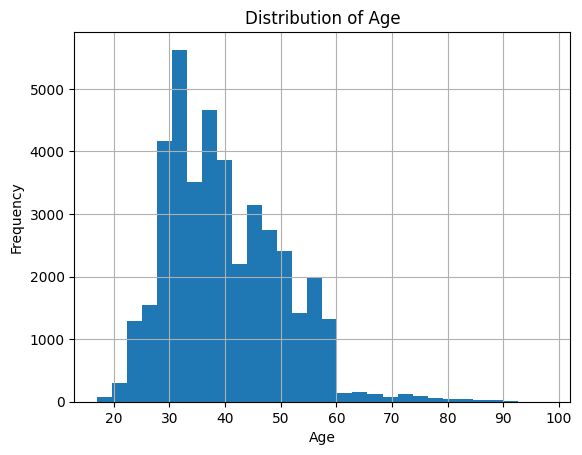

In [268]:
# A. Investigate the spread of values
# Plot overall distribution via a Histogram

bank['age'].hist(bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

**KEY INSIGHTS FROM THE HISTOGRAM**</br>

1. Most customers are between ages 30–50.</br>
2. The bank’s core customer population consists primarily of working-age adults.</br>
3. The distribution is right-skewed. Most customers are younger/middle-aged while a smaller number of elderly customers exist.

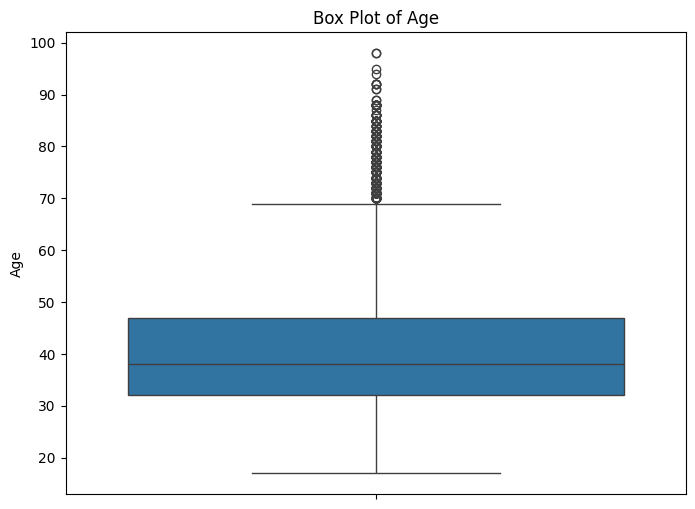

In [269]:
# Investigate the spread of values & outliers via a Boxplot

plt.figure(figsize=(8,6))

sns.boxplot(y=bank['age'])

plt.title('Box Plot of Age')
plt.ylabel('Age')

plt.show()

**KEY INSIGHTS FROM THE BOX PLOT (AGE)**</br>

1. Median age is around 38 years old.</br>
2. Majority of customers are middle-aged, around 32 to 47 years old.</br> 
3. The bank’s primary customer base consists largely of working-age adults.
4. While most customers are middle-aged, a smaller number of significantly older customers exist in the dataset.

**What do the outliers represent? Are they meaningful or are they more likely to be errors?**</br>
Outliers exist approximately above age 69.</br>
These are likely retirees, long-term customers, financially conservative savers.</br>
These are genuine customer segments and not a data quality issue.</br>

**Are the outliers "different" from our main population in a meaningful way?**</br>
Compared to the main customer population, elderly customers may have different savings behavior, lower risk appetite, and greater interest in stable financial products.</br>

**Do the outliers represent customers that I would still want to make predictions on?**</br>
Yes. Because elderly customers are legitimate banking customers, they may be financially valuable and they may actually have higher savings/deposit tendencies.</br>

**2. CAMPAIGN**</br>
Number of contacts performed during this campaign and for this customer

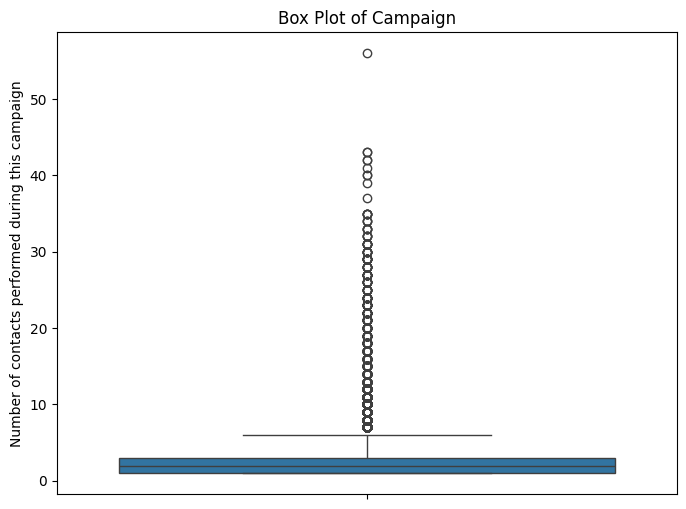

In [270]:
# Investigate the spread of values & outliers via a Boxplot

plt.figure(figsize=(8,6))

sns.boxplot(y=bank['campaign'])

plt.title('Box Plot of Campaign')
plt.ylabel('Number of contacts performed during this campaign')

plt.show()

In [271]:
bank['campaign'].value_counts()

campaign
1     17642
2     10570
3      5341
4      2651
5      1599
6       979
7       629
8       400
9       283
10      225
11      177
12      125
13       92
14       69
17       58
16       51
15       51
18       33
20       30
19       26
21       24
22       17
23       16
24       15
27       11
29       10
25        8
28        8
26        8
31        7
30        7
35        5
32        4
33        4
34        3
42        2
40        2
43        2
56        1
39        1
41        1
37        1
Name: count, dtype: int64

**KEY INSIGHTS FROM THE BOX PLOT (CAMPAIGN)**</br>

1. The majority of customers were contacted a relatively small number of times, around 1 to 3 times during the campaign. </br>
2. There is a very long upper tail extending up to 56 contacts during the campaign. This indicates that a small subset of customers received significantly more campaign contacts than most customers.
2. Many outliers exist beyond approximately 6 contacts. 

**What do the outliers represent?**</br>
The outliers likely represent:
- difficult-to-convert customers
- customers repeatedly targeted by sales teams
- highly engaged or previously interested customers
- inefficient campaign targeting
- persistent follow-up efforts.</br>

**Are they meaningful or are they more likely to be errors?**</br>
These are likely meaningful business observations rather than random data errors.
This may indicate lower responsiveness, uncertainty from sales teams, repeated unsuccessful persuasion attempts or higher sales effort required.

**Are the outliers "different" from our main population in a meaningful way?**</br>
Repeated customer contact is operationally possible and the outliers form a gradual distribution rather than isolated suspicious spikes.</br>
There is no evidence suggesting corrupted data, impossible values, negative contacts or unrealistic entries.

**Do the outliers represent customers that I would still want to make predictions on?**</br>
Yes, These customers are real campaign participants, may continue appearing in future campaigns and represent important operational scenarios.</br>

**3. PDAYS**</br>
Number of days that passed by after the customer was last contacted from a previous campaign (999 means client was not previously contacted)

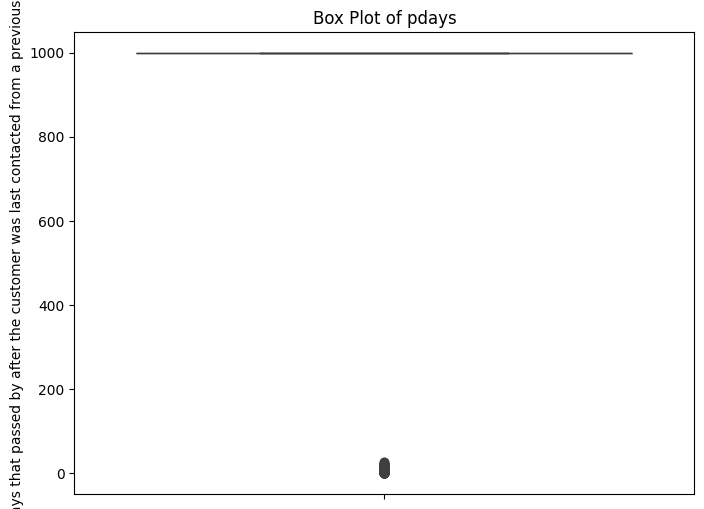

In [272]:
# Investigate the spread of values & outliers via a Boxplot

plt.figure(figsize=(8,6))

sns.boxplot(y=bank['pdays'])

plt.title('Box Plot of pdays')
plt.ylabel('Number of days that passed by after the customer was last contacted from a previous campaign')

plt.show()

In [273]:
bank['pdays'].value_counts()

pdays
999    39673
3        439
6        412
4        118
9         64
2         61
7         60
12        58
10        52
5         46
13        36
11        28
1         26
15        24
14        20
8         18
0         15
16        11
17         8
18         7
22         3
19         3
21         2
25         1
26         1
27         1
20         1
Name: count, dtype: int64

In [274]:
bank['pdays'].value_counts(normalize=True)

pdays
999    0.963217
3      0.010658
6      0.010003
4      0.002865
9      0.001554
2      0.001481
7      0.001457
12     0.001408
10     0.001263
5      0.001117
13     0.000874
11     0.000680
1      0.000631
15     0.000583
14     0.000486
8      0.000437
0      0.000364
16     0.000267
17     0.000194
18     0.000170
22     0.000073
19     0.000073
21     0.000049
25     0.000024
26     0.000024
27     0.000024
20     0.000024
Name: proportion, dtype: float64

**KEY INSIGHTS FROM THE BOX PLOT (PDAYS)**</br>

1. Vast majority of customers (96%) were never previously contacted.</br>
2. The lower values represent customers who were actually contacted previously, around 0 to 30 days.
3. This variable is not a normal continuous numeric variable because 999 is actually a categorical flag which means no contact.

**What do the outliers represent?**</br>
The outliers are being represented with the lower values, the 4% population of customers who had previous campaign interactions, repeat-contact customers, and previously engaged leads.</br>

**Are they meaningful or are they more likely to be errors?**</br>
They are meaningful because customers with prior interactions may behave differently and prior engagement often affects future subscription likelihood.</br>
These values are valid and operationally meaningful.</br>
There is no evidence suggesting corruption of data, impossible values or incorrect entries.</br>

**Are the outliers "different" from our main population in a meaningful way?**</br>
Yes. The 2 populations in this variable shows a major behavioral distinction.</br>
999: never previously contacted
0–30+: previously contacted customers


**Do the outliers represent customers that I would still want to make predictions on?**</br>
Yes. Prior engagement is often highly predictive in marketing campaigns.</br>

**4. PREVIOUS**</br>
Number of contacts performed before this campaign and for this customer

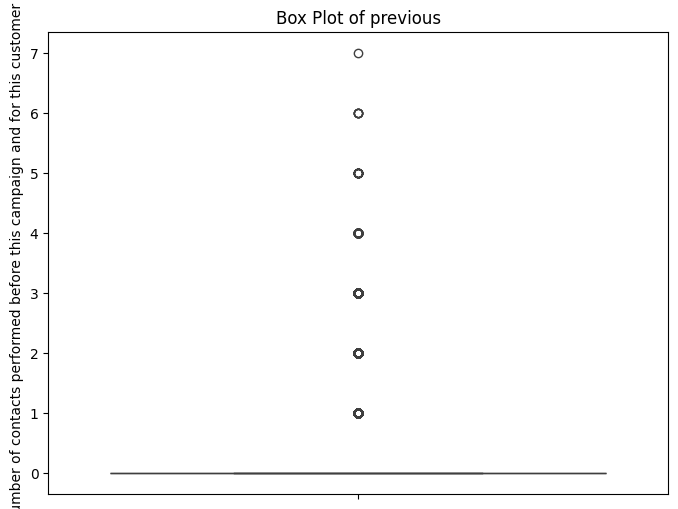

In [275]:
# Investigate the spread of values & outliers via a Boxplot

plt.figure(figsize=(8,6))

sns.boxplot(y=bank['previous'])

plt.title('Box Plot of previous')
plt.ylabel('Number of contacts performed before this campaign and for this customer')

plt.show()

In [276]:
bank['previous'].value_counts()

previous
0    35563
1     4561
2      754
3      216
4       70
5       18
6        5
7        1
Name: count, dtype: int64

In [277]:
bank['previous'].value_counts(normalize=True)

previous
0    0.863431
1    0.110736
2    0.018306
3    0.005244
4    0.001700
5    0.000437
6    0.000121
7    0.000024
Name: proportion, dtype: float64

**KEY INSIGHTS FROM THE BOX PLOT (PREVIOUS)**</br>

1. Majority of customers, around 86%, had never been contacted before prior campaigns.</br>
2. Only a small subset of customers, around 14%, had previous contacts, around 1-7 contacts.

**What do the outliers represent?**</br>
The outlier points represent customers who had prior campaign interactions, were contacted in earlier marketing efforts, and may already have some relationship/history with the bank.</br>

**Are they meaningful or are they more likely to be errors?**</br>
They are highly meaningful. The values are small and operationally plausible.
There are no suspicious values such as negative contacts or extremely large impossible counts.</br>

**Are the outliers "different" from our main population in a meaningful way?**</br>
Yes. The 2 populations in this variable shows a major behavioral distinction.</br>
0: no prior campaign contacts</br>
1-7: previously contacted customers</br>
Prior interaction history may strongly influence campaign response behavior.

**Do the outliers represent customers that I would still want to make predictions on?**</br>
Yes. These customers are operationally relevant, may reappear in future campaigns and contain valuable behavioral information.</br>

**5. emp.var.rate**</br>
Quarterly economic indicator (employment variation rate) at time of contact

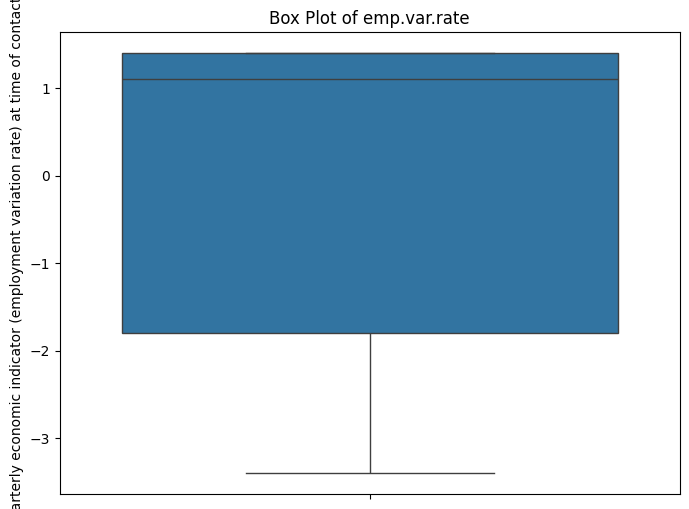

In [278]:
# Investigate the spread of values & outliers via a Boxplot

plt.figure(figsize=(8,6))

sns.boxplot(y=bank['emp.var.rate'])

plt.title('Box Plot of emp.var.rate')
plt.ylabel('Quarterly economic indicator (employment variation rate) at time of contact')

plt.show()

In [279]:
bank['emp.var.rate'].value_counts(normalize=True)

emp.var.rate
 1.4    0.394144
-1.8    0.222978
 1.1    0.188477
-0.1    0.089419
-2.9    0.040376
-3.4    0.026003
-1.7    0.018768
-1.1    0.015417
-3.0    0.004176
-0.2    0.000243
Name: proportion, dtype: float64

**KEY INSIGHTS FROM THE BOX PLOT (Employment Variation Rate)**</br>

1. The distribution spans both negative and positive economic conditions, ranging from -3.4 to 1.4.</br>
    - economic contraction (negative values)
    - economic growth (positive values)
    Customers were contacted during different economic environments.
2. The data appears clustered around a few discrete values such as 1.4 (39%), -1.8 (22%) and 1.1 (19%), mostly during economic growth

**What do the outliers represent?**</br>
There is no significant outliers are present.</br>

**Are they meaningful or likely to be errors?**</br>
The lower values (-3.4, -3.0, -2.9) likely represent recessionary periods or weaker employment conditions and not errors. These are economically meaningful observations.</br>

**Is this variable still be meaningful in some way?**</br>
Yes, may potentially be meaningful.</br>
Customers contacted during positive employment environments may behave differently from those contacted during recessionary or weaker employment periods.

**Is this variable useful to represent customers that I would still want to make predictions on?**</br>
Yes. Macroeconomic variables often become may help the model learn economic-cycle behavior, customer sentiment shifts and market timing effects.</br>

No outlier treatment needed.

**6. euribor3m**</br>
Euribor 3-month rate. European central bank interest rate, can be used as a proxy for the state of the economy at time of customer contact

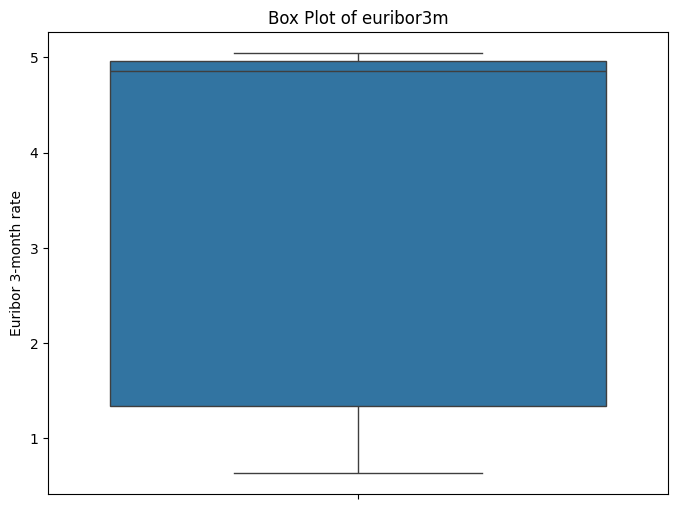

In [280]:
# Investigate the spread of values & outliers via a Boxplot

plt.figure(figsize=(8,6))

sns.boxplot(y=bank['euribor3m'])

plt.title('Box Plot of euribor3m')
plt.ylabel('Euribor 3-month rate')

plt.show()

In [281]:
bank['euribor3m'].value_counts(normalize=True)

euribor3m
4.857    0.069632
4.962    0.063441
4.963    0.060382
4.961    0.046178
4.856    0.029377
           ...   
0.969    0.000024
0.933    0.000024
0.956    0.000024
1.045    0.000024
1.047    0.000024
Name: proportion, Length: 316, dtype: float64

**KEY INSIGHTS FROM THE BOX PLOT (Euribor 3-month interest rate)**</br>

1. Customers were contacted during very different interest-rate environments, with values ranging from 0.6 to 5.0.</br>
2. Multiple customers were contacted under the same macroeconomic conditions.</br>
3. A large portion of campaigns occurred during relatively high interest-rate environments.</br>

**What do the outliers represent?**</br>
There is no major statistical outliers present.</br>
The lower interest rate values likely correspond to expansionary monetary policy, low-interest-rate economic periods or weaker economic environments.</br>

**Are they meaningful or are they more likely to be errors?**</br>
These are valid macroeconomic observations.</br>

**Are the outliers "different" from our main population in a meaningful way?**</br>
Potentially yes. Interest-rate environments may strongly influence savings attractiveness, customer investment behavior and willingness to lock money into deposits.</br>

**Do the outliers represent customers that I would still want to make predictions on?**</br>
This Macroeconomic indicator captures economic-cycle effects, monetary policy conditions and financial attractiveness of deposit products.</br>

No outlier treatment needed.

**7. cons.price.idx**</br>
Quarterly economic indicator (consumer price index) at time of contact

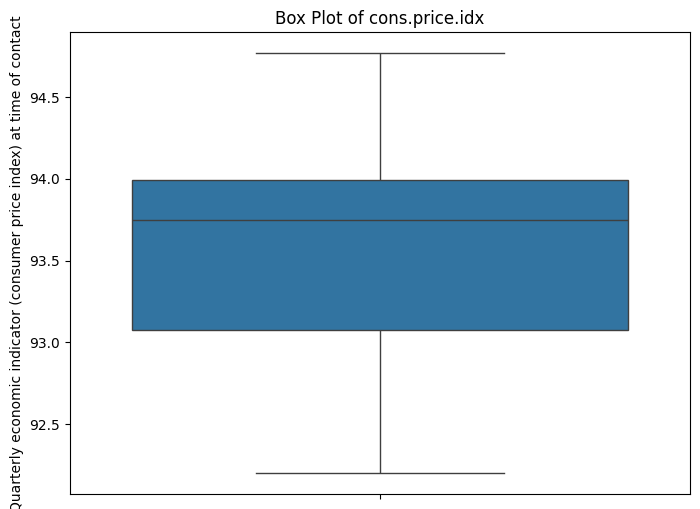

In [282]:
# Investigate the spread of values & outliers via a Boxplot

plt.figure(figsize=(8,6))

sns.boxplot(y=bank['cons.price.idx'])

plt.title('Box Plot of cons.price.idx')
plt.ylabel('Quarterly economic indicator (consumer price index) at time of contact')

plt.show()

In [283]:
bank['cons.price.idx'].value_counts(normalize=True)

cons.price.idx
93.994    0.188477
93.918    0.162305
92.893    0.140672
93.444    0.125643
94.465    0.106196
93.200    0.087793
93.075    0.059678
92.201    0.018695
92.963    0.017359
92.431    0.010853
92.649    0.008668
94.215    0.007551
94.199    0.007357
92.843    0.006847
92.379    0.006482
93.369    0.006410
94.027    0.005657
94.055    0.005560
93.876    0.005147
94.601    0.004953
92.469    0.004322
93.749    0.004225
92.713    0.004176
94.767    0.003108
93.798    0.001627
92.756    0.000243
Name: proportion, dtype: float64

**KEY INSIGHTS FROM THE BOX PLOT (Consumer Price Index)**</br>

1. Consumer prices did not fluctuate dramatically across the observed campaign timeframe.</br>
3. Multiple customers were contacted under the same macroeconomic conditions.</br>

**What do the outliers represent?**</br>
There is no significant statistical outliers are present. The values remain within a narrow and plausible economic range.</br>

**Are they meaningful or are they more likely to be errors?**</br>
These are valid macroeconomic measurements.</br>

**Are the outliers "different" from our main population in a meaningful way?**</br>
Potentially yes. Customers contacted during higher CPI environments may behave differently from those contacted during lower inflation periods.</br>

**Do the outliers represent customers that I would still want to make predictions on?**</br>
Macroeconomic indicators often contribute valuable predictive information in marketing and financial models.</br>

No outlier treatment needed.

**8. cons.conf.idx**</br>
Quarterly economic indicator (consumer confidence index) at time of contact

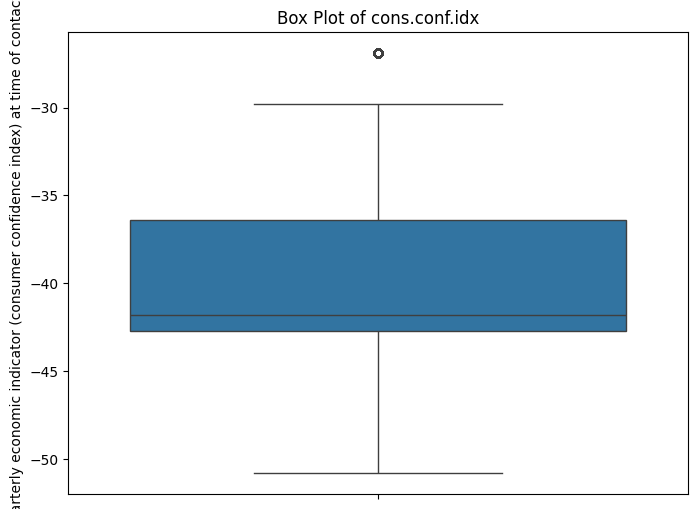

In [284]:
# Investigate the spread of values & outliers via a Boxplot

plt.figure(figsize=(8,6))

sns.boxplot(y=bank['cons.conf.idx'])

plt.title('Box Plot of cons.conf.idx')
plt.ylabel('Quarterly economic indicator (consumer confidence index) at time of contact')

plt.show()

In [285]:
bank['cons.conf.idx'].value_counts(normalize=True)

cons.conf.idx
-36.4    0.188477
-42.7    0.162305
-46.2    0.140672
-36.1    0.125643
-41.8    0.106196
-42.0    0.087793
-47.1    0.059678
-31.4    0.018695
-40.8    0.017359
-26.9    0.010853
-30.1    0.008668
-40.3    0.007551
-37.5    0.007357
-50.0    0.006847
-29.8    0.006482
-34.8    0.006410
-38.3    0.005657
-39.8    0.005560
-40.0    0.005147
-49.5    0.004953
-33.6    0.004322
-34.6    0.004225
-33.0    0.004176
-50.8    0.003108
-40.4    0.001627
-45.9    0.000243
Name: proportion, dtype: float64

**KEY INSIGHTS FROM THE BOX PLOT (Consumer Confidence Index)**</br>

1. Customers were primarily contacted during periods of relatively weak or cautious consumer confidence.</br>
2. Customer campaigns occurred across different consumer confidence environments.
3. A small upper outlier exists around -26 to -27. This represents unusually high consumer confidence relative to the rest of the dataset and a more optimistic economic environment

**What do the outliers represent?**</br>
The higher-confidence outlier likely corresponds to a stronger economic period, increased consumer optimism, favorable financial conditions.</br>
Customers contacted during these periods may behave differently financially, have different savings priorities and respond differently to deposit campaigns. </br>

**Are they meaningful or are they more likely to be errors?**</br>
These are valid macroeconomic observations.</br>

**Are the outliers "different" from our main population in a meaningful way?**</br>
Potentially yes. Customers contacted during higher confidence periods may differ from those contacted during lower confidence periods.</br>

**Do the outliers represent customers that I would still want to make predictions on?**</br>
Macroeconomic sentiment indicators often influence customer financial decisions, savings behavior and marketing responsiveness.</br>

No outlier treatment needed.

**9. nr.employed**</br>
Quarterly economic indicator (number of employees) at time of contact

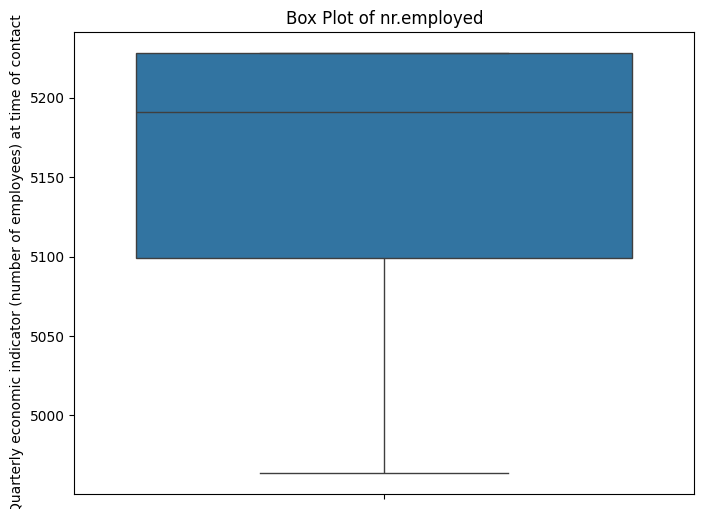

In [286]:
# Investigate the spread of values & outliers via a Boxplot

plt.figure(figsize=(8,6))

sns.boxplot(y=bank['nr.employed'])

plt.title('Box Plot of nr.employed')
plt.ylabel('Quarterly economic indicator (number of employees) at time of contact')

plt.show()

In [287]:
bank['nr.employed'].value_counts(normalize=True)

nr.employed
5228.1    0.394144
5099.1    0.207196
5191.0    0.188477
5195.8    0.089419
5076.2    0.040376
5017.5    0.026003
4991.6    0.018768
5008.7    0.015781
4963.6    0.015417
5023.5    0.004176
5176.3    0.000243
Name: proportion, dtype: float64

**KEY INSIGHTS FROM THE BOX PLOT (Number of Employees)**</br>

1. Employment conditions remained relatively stable across most campaign periods.</br>
2. There's no major statistical outliers present.</br>

**What do the outliers represent?**</br>
Lower employment values likely correspond to weaker economic conditions. </br>

**Are they meaningful or are they more likely to be errors?**</br>
These are valid macroeconomic observations.</br>

**Are the outliers "different" from our main population in a meaningful way?**</br>
Potentially yes. Customers contacted during weaker employment periods may behave differently from those contacted during stronger labor-market conditions.</br>

**Do the outliers represent customers that I would still want to make predictions on?**</br>
Macroeconomic labor indicators can help the model learn economic-cycle effects, customer confidence shifts, and timing-related behavior.</br>

No outlier treatment needed.

#### 4. Deal with outliers

Based on your answers to question 3, decide whether to drop or keep your outliers

**I will keep the outliers for the following variables and create additional fields for easier readability and analysis:**</br>
1. AGE - Create age buckets
2. PDAYS - Create a prior contact flag
3. CAMPAIGN - Create contact buckets

In [289]:
# Create Age Buckets

bank['age_group'] = pd.cut(
    bank['age'],
    bins=[15,25,35,45,55,65,100],
    labels=[
        '16-25',
        '26-35',
        '36-45',
        '46-55',
        '56-65',
        '65+'
    ]
)

bank

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,default_fillna,age_group
0,56,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0.0,56-65
1,57,services,married,high.school,NaN,0.0,0.0,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0.0,56-65
2,37,services,married,high.school,0.0,1.0,0.0,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0.0,36-45
3,40,admin.,married,basic.6y,0.0,0.0,0.0,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0.0,36-45
4,56,services,married,high.school,0.0,0.0,1.0,telephone,may,mon,...,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,0.0,56-65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,0.0,1.0,0.0,cellular,nov,fri,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,0.0,65+
41184,46,blue-collar,married,professional.course,0.0,0.0,0.0,cellular,nov,fri,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,0.0,46-55
41185,56,retired,married,university.degree,0.0,1.0,0.0,cellular,nov,fri,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,0,0.0,56-65
41186,44,technician,married,professional.course,0.0,0.0,0.0,cellular,nov,fri,...,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,1,0.0,36-45


In [290]:
# View the data
bank['age_group'].value_counts()

age_group
26-35    14847
36-45    12844
46-55     8249
56-65     2963
16-25     1666
65+        619
Name: count, dtype: int64

In [291]:
# Create a prior-contact flag for pdays

bank['previously_contacted'] = (
    bank['pdays'] != 999
).astype(int)

# Clean pdays by replacing 999 with NaN (missing value)
# This prevents misleading averages, distorted boxplots/histograms and incorrect correlations

bank['pdays_cleaned'] = (
    bank['pdays']
    .replace(999, np.nan)
    .astype('Int64')
)


In [292]:
# View the data
bank[['previously_contacted', 'pdays']].value_counts()

previously_contacted  pdays
0                     999      39673
1                     3          439
                      6          412
                      4          118
                      9           64
                      2           61
                      7           60
                      12          58
                      10          52
                      5           46
                      13          36
                      11          28
                      1           26
                      15          24
                      14          20
                      8           18
                      0           15
                      16          11
                      17           8
                      18           7
                      22           3
                      19           3
                      21           2
                      25           1
                      26           1
                      27           1
          

In [293]:
# View the data
bank[['pdays_cleaned', 'pdays']].value_counts()

pdays_cleaned  pdays
3              3        439
6              6        412
4              4        118
9              9         64
2              2         61
7              7         60
12             12        58
10             10        52
5              5         46
13             13        36
11             11        28
1              1         26
15             15        24
14             14        20
8              8         18
0              0         15
16             16        11
17             17         8
18             18         7
22             22         3
19             19         3
21             21         2
25             25         1
26             26         1
27             27         1
20             20         1
Name: count, dtype: int64

In [294]:
# Create contact buckets for campaign

bank['campaign_group'] = pd.cut(
    bank['campaign'],
    bins=[0,1,3,5,10,100],
    labels=[
        '1 Contact',
        '2-3 Contacts',
        '4-5 Contacts',
        '6-10 Contacts',
        '10+ Contacts'
    ]
)

bank

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,default_fillna,age_group,previously_contacted,pdays_cleaned,campaign_group
0,56,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,0,0.0,56-65,0,<NA>,1 Contact
1,57,services,married,high.school,NaN,0.0,0.0,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,0,0.0,56-65,0,<NA>,1 Contact
2,37,services,married,high.school,0.0,1.0,0.0,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,0,0.0,36-45,0,<NA>,1 Contact
3,40,admin.,married,basic.6y,0.0,0.0,0.0,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,0,0.0,36-45,0,<NA>,1 Contact
4,56,services,married,high.school,0.0,0.0,1.0,telephone,may,mon,...,93.994,-36.4,4.857,5191.0,0,0.0,56-65,0,<NA>,1 Contact
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,0.0,1.0,0.0,cellular,nov,fri,...,94.767,-50.8,1.028,4963.6,1,0.0,65+,0,<NA>,1 Contact
41184,46,blue-collar,married,professional.course,0.0,0.0,0.0,cellular,nov,fri,...,94.767,-50.8,1.028,4963.6,0,0.0,46-55,0,<NA>,1 Contact
41185,56,retired,married,university.degree,0.0,1.0,0.0,cellular,nov,fri,...,94.767,-50.8,1.028,4963.6,0,0.0,56-65,0,<NA>,2-3 Contacts
41186,44,technician,married,professional.course,0.0,0.0,0.0,cellular,nov,fri,...,94.767,-50.8,1.028,4963.6,1,0.0,36-45,0,<NA>,1 Contact


In [295]:
# View the data
bank['campaign_group'].value_counts()

campaign_group
1 Contact        17642
2-3 Contacts     15911
4-5 Contacts      4250
6-10 Contacts     2516
10+ Contacts       869
Name: count, dtype: int64

#### 5. Investigate some of the categorical columns

First, identify which columns are categorical (including binary)

Investigate the breakdown of values of some of these columns. If you notice any odd values, investigate them and deal with them (either drop or keep them).

In [296]:
# Show categorical columns 
bank.select_dtypes(include=['object']).columns

/var/folders/5x/h0y6d2h9185gj8rngbqzdl4r0000gn/T/ipykernel_1223/1190305250.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  bank.select_dtypes(include=['object']).columns


Index(['job', 'marital', 'education', 'contact', 'month', 'day_of_week',
       'poutcome'],
      dtype='str')

**1. JOB**

In [297]:
# Number of Unique Values
bank['job'].nunique()

12

In [298]:
# Value Breakdown
bank['job'].value_counts(dropna=False)

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

In [299]:
# Percentage Breakdown
round(bank['job'].value_counts(normalize=True, dropna=False) * 100, 2)

job
admin.           25.30
blue-collar      22.47
technician       16.37
services          9.64
management        7.10
retired           4.18
entrepreneur      3.54
self-employed     3.45
housemaid         2.57
unemployed        2.46
student           2.12
unknown           0.80
Name: proportion, dtype: float64

**OBSERVATION**
- Top 3 occupations are admin (25.3%), blue-collar (22.5%) and technician (16.3%)
- unknown only represents 0.8%
- Keep unknown as it may carry predictive value and it has only a very low proportion.
- Replace with a more business-friendly term

In [300]:
bank['job_cleaned'] = bank['job'].replace({
    'unknown': 'Other'
})

bank

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,cons.conf.idx,euribor3m,nr.employed,y,default_fillna,age_group,previously_contacted,pdays_cleaned,campaign_group,job_cleaned
0,56,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,may,mon,...,-36.4,4.857,5191.0,0,0.0,56-65,0,<NA>,1 Contact,housemaid
1,57,services,married,high.school,NaN,0.0,0.0,telephone,may,mon,...,-36.4,4.857,5191.0,0,0.0,56-65,0,<NA>,1 Contact,services
2,37,services,married,high.school,0.0,1.0,0.0,telephone,may,mon,...,-36.4,4.857,5191.0,0,0.0,36-45,0,<NA>,1 Contact,services
3,40,admin.,married,basic.6y,0.0,0.0,0.0,telephone,may,mon,...,-36.4,4.857,5191.0,0,0.0,36-45,0,<NA>,1 Contact,admin.
4,56,services,married,high.school,0.0,0.0,1.0,telephone,may,mon,...,-36.4,4.857,5191.0,0,0.0,56-65,0,<NA>,1 Contact,services
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,0.0,1.0,0.0,cellular,nov,fri,...,-50.8,1.028,4963.6,1,0.0,65+,0,<NA>,1 Contact,retired
41184,46,blue-collar,married,professional.course,0.0,0.0,0.0,cellular,nov,fri,...,-50.8,1.028,4963.6,0,0.0,46-55,0,<NA>,1 Contact,blue-collar
41185,56,retired,married,university.degree,0.0,1.0,0.0,cellular,nov,fri,...,-50.8,1.028,4963.6,0,0.0,56-65,0,<NA>,2-3 Contacts,retired
41186,44,technician,married,professional.course,0.0,0.0,0.0,cellular,nov,fri,...,-50.8,1.028,4963.6,1,0.0,36-45,0,<NA>,1 Contact,technician


In [301]:
# Value Breakdown of the new field
bank['job_cleaned'].value_counts(dropna=False)

job_cleaned
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
Other              330
Name: count, dtype: int64

**2. MARITAL STATUS**

In [302]:
# Number of Unique Values
bank['marital'].nunique()

4

In [303]:
# Value Breakdown
bank['marital'].value_counts(dropna=False)

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

In [304]:
# Percentage Breakdown
round(bank['marital'].value_counts(normalize=True, dropna=False) * 100, 2)

marital
married     60.52
single      28.09
divorced    11.20
unknown      0.19
Name: proportion, dtype: float64

**OBSERVATION**
- Mostly married (60.5%) and unknown only 0.19%.
- No data cleaning required.

**3. EDUCATION**

In [305]:
# Number of Unique Values
bank['education'].nunique()

8

In [306]:
# Value Breakdown
bank['education'].value_counts(dropna=False)

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

In [307]:
# Percentage Breakdown
round(bank['education'].value_counts(normalize=True, dropna=False) * 100, 2)

education
university.degree      29.54
high.school            23.10
basic.9y               14.68
professional.course    12.73
basic.4y               10.14
basic.6y                5.56
unknown                 4.20
illiterate              0.04
Name: proportion, dtype: float64

**OBSERVATION**
- University degree is largest group (29.5%) and illiterate only 18 rows (0.04%).</br>
- Consolidate education levels for basic. These represent different tiers of basic education based on the number of years of schooling completed:</br>
        - basic.4y: Represents 4 years of primary education (typically finishing around age 10).</br>
        - basic.6y: Represents 6 years of elementary or primary education (typically finishing around age 12).</br>
        - basic.9y: Represents 9 years of combined primary and lower-secondary education (equivalent to completing junior high or middle school, typically finishing around age 15).</br>

In [308]:
# Consolidate education levels for Basic

bank['education_cleaned'] = bank['education'].replace({
    'basic.4y': 'Basic',
    'basic.6y': 'Basic',
    'basic.9y': 'Basic'
})

bank

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,euribor3m,nr.employed,y,default_fillna,age_group,previously_contacted,pdays_cleaned,campaign_group,job_cleaned,education_cleaned
0,56,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,may,mon,...,4.857,5191.0,0,0.0,56-65,0,<NA>,1 Contact,housemaid,Basic
1,57,services,married,high.school,NaN,0.0,0.0,telephone,may,mon,...,4.857,5191.0,0,0.0,56-65,0,<NA>,1 Contact,services,high.school
2,37,services,married,high.school,0.0,1.0,0.0,telephone,may,mon,...,4.857,5191.0,0,0.0,36-45,0,<NA>,1 Contact,services,high.school
3,40,admin.,married,basic.6y,0.0,0.0,0.0,telephone,may,mon,...,4.857,5191.0,0,0.0,36-45,0,<NA>,1 Contact,admin.,Basic
4,56,services,married,high.school,0.0,0.0,1.0,telephone,may,mon,...,4.857,5191.0,0,0.0,56-65,0,<NA>,1 Contact,services,high.school
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,0.0,1.0,0.0,cellular,nov,fri,...,1.028,4963.6,1,0.0,65+,0,<NA>,1 Contact,retired,professional.course
41184,46,blue-collar,married,professional.course,0.0,0.0,0.0,cellular,nov,fri,...,1.028,4963.6,0,0.0,46-55,0,<NA>,1 Contact,blue-collar,professional.course
41185,56,retired,married,university.degree,0.0,1.0,0.0,cellular,nov,fri,...,1.028,4963.6,0,0.0,56-65,0,<NA>,2-3 Contacts,retired,university.degree
41186,44,technician,married,professional.course,0.0,0.0,0.0,cellular,nov,fri,...,1.028,4963.6,1,0.0,36-45,0,<NA>,1 Contact,technician,professional.course


In [309]:
# Change illiterate to a more non-bias term
bank['education_cleaned'] = bank['education_cleaned'].replace({
    'illiterate': 'Other'
})

In [310]:
# View Data
bank['education'].value_counts(dropna=False)

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

**4. CONTACT**

In [311]:
# Number of Unique Values
bank['contact'].nunique()

2

In [312]:
# Value Breakdown
bank['contact'].value_counts(dropna=False)

contact
cellular     26144
telephone    15044
Name: count, dtype: int64

In [313]:
# Percentage Breakdown
round(bank['contact'].value_counts(normalize=True, dropna=False) * 100, 2)

contact
cellular     63.47
telephone    36.53
Name: proportion, dtype: float64

**OBSERVATION**
- Majority of customers were contacted via cellular (63.5%) vs telephone (36.5%).
- Cellular contact may indicate a more modern or responsive customer segment.
- No abnormal values detected.

Keep as-is.

**5. MONTH**

In [314]:
# Number of Unique Values
bank['month'].nunique()

10

In [315]:
# Value Breakdown
bank['month'].value_counts(dropna=False)

month
may    13769
jul     7174
aug     6178
jun     5318
nov     4101
apr     2632
oct      718
sep      570
mar      546
dec      182
Name: count, dtype: int64

In [316]:
# Percentage Breakdown
round(bank['month'].value_counts(normalize=True, dropna=False) * 100, 2)

month
may    33.43
jul    17.42
aug    15.00
jun    12.91
nov     9.96
apr     6.39
oct     1.74
sep     1.38
mar     1.33
dec     0.44
Name: proportion, dtype: float64

**OBSERVATION**
- Majority of campaigns occurred in May (33.4%), July (17.4%), August (15.0%) and June (12.9%)
- Campaigns are heavily concentrated in specific months (May to August), suggesting seasonality or operational campaign pushes.
- All valid values.
- Keep as ordered categorical variable.

**6. DAY_OF_WEEK**

In [318]:
# Number of Unique Values
bank['day_of_week'].nunique()

5

In [319]:
# Value Breakdown
bank['day_of_week'].value_counts(dropna=False)

day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Name: count, dtype: int64

In [320]:
# Percentage Breakdown
round(bank['day_of_week'].value_counts(normalize=True, dropna=False) * 100, 2)

day_of_week
thu    20.94
mon    20.67
wed    19.75
tue    19.64
fri    19.00
Name: proportion, dtype: float64

**OBSERVATION**
- Very evenly distributed across weekdays (~19–21% each).
- Campaign activity appears operationally balanced across weekdays.
- No suspicious values.
- Keep as-is.

**7. POUTCOME**

In [321]:
# Number of Unique Values
bank['poutcome'].nunique()

3

In [322]:
# Value Breakdown
bank['poutcome'].value_counts(dropna=False)

poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

In [323]:
# Percentage Breakdown
round(bank['poutcome'].value_counts(normalize=True, dropna=False) * 100, 2)

poutcome
nonexistent    86.34
failure        10.32
success         3.33
Name: proportion, dtype: float64

**OBSERVATION**
- Most customers likely had no previous campaign interaction (86.3%).
- Previous campaign history may be a strong predictor of subscription success.
- No odd values.
- Keep as-is.

**8. DEFAULT**

In [324]:
# Number of Unique Values
bank['default'].nunique()

2

In [325]:
# Value Breakdown
bank['default'].value_counts(dropna=False)

default
0.0    32588
NaN     8597
1.0        3
Name: count, dtype: int64

In [326]:
# Percentage Breakdown
round(bank['default'].value_counts(normalize=True, dropna=False) * 100, 2)

default
0.0    79.12
NaN    20.87
1.0     0.01
Name: proportion, dtype: float64

**OBSERVATION**
- No default (79.1%), missing values (20.9%), Have defaulted (0.01%).
- Only 3 observations for customers with credit default.
- This feature has near-zero variance, meaning almost all rows contain the same value, with very little variation across observations and likely not useful for prediction
- It may cause modeling instability because rare categories can lead to overfitting, unstable coefficients and unreliable probabilities.
- To drop this column.

**9. HOUSING**

In [327]:
# Number of Unique Values
bank['housing'].nunique()

2

In [328]:
# Value Breakdown
bank['housing'].value_counts(dropna=False)

housing
1.0    21576
0.0    18622
NaN      990
Name: count, dtype: int64

In [329]:
# Percentage Breakdown
round(bank['housing'].value_counts(normalize=True, dropna=False) * 100, 2)

housing
1.0    52.38
0.0    45.21
NaN     2.40
Name: proportion, dtype: float64

**OBSERVATION**
- No invalid values, but missing values should be investigated.
- Handle missing values.

In [330]:
# Create explicit “Unknown” category to preserve missing values

bank['housing'] = bank['housing'].fillna(-1)

In [331]:
# View data
bank['housing'].value_counts(dropna=False)

housing
 1.0    21576
 0.0    18622
-1.0      990
Name: count, dtype: int64

**10. LOAN**

In [332]:
# Number of Unique Values
bank['loan'].nunique()

2

In [333]:
# Value Breakdown
bank['loan'].value_counts(dropna=False)

loan
0.0    33950
1.0     6248
NaN      990
Name: count, dtype: int64

In [334]:
# Percentage Breakdown
round(bank['loan'].value_counts(normalize=True, dropna=False) * 100, 2)

loan
0.0    82.43
1.0    15.17
NaN     2.40
Name: proportion, dtype: float64

**OBSERVATION**
- Majority do not have personal loans (82.4%).
- There are missing values (2.4%)
- Handle missing values.

In [335]:
# Create explicit “Unknown” category to preserve missing values

bank['loan'] = bank['loan'].fillna(-1)

In [336]:
# View data
bank['loan'].value_counts(dropna=False)

loan
 0.0    33950
 1.0     6248
-1.0      990
Name: count, dtype: int64

**11. Y**

In [337]:
# Number of Unique Values
bank['y'].nunique()

2

In [338]:
# Value Breakdown
bank['y'].value_counts(dropna=False)

y
0    36548
1     4640
Name: count, dtype: int64

In [339]:
# Percentage Breakdown
round(bank['y'].value_counts(normalize=True, dropna=False) * 100, 2)

y
0    88.73
1    11.27
Name: proportion, dtype: float64

**OBSERVATION**
- Campaign take-up is only 11%
- Keep as-is

In [340]:
bank

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,euribor3m,nr.employed,y,default_fillna,age_group,previously_contacted,pdays_cleaned,campaign_group,job_cleaned,education_cleaned
0,56,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,may,mon,...,4.857,5191.0,0,0.0,56-65,0,<NA>,1 Contact,housemaid,Basic
1,57,services,married,high.school,NaN,0.0,0.0,telephone,may,mon,...,4.857,5191.0,0,0.0,56-65,0,<NA>,1 Contact,services,high.school
2,37,services,married,high.school,0.0,1.0,0.0,telephone,may,mon,...,4.857,5191.0,0,0.0,36-45,0,<NA>,1 Contact,services,high.school
3,40,admin.,married,basic.6y,0.0,0.0,0.0,telephone,may,mon,...,4.857,5191.0,0,0.0,36-45,0,<NA>,1 Contact,admin.,Basic
4,56,services,married,high.school,0.0,0.0,1.0,telephone,may,mon,...,4.857,5191.0,0,0.0,56-65,0,<NA>,1 Contact,services,high.school
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,0.0,1.0,0.0,cellular,nov,fri,...,1.028,4963.6,1,0.0,65+,0,<NA>,1 Contact,retired,professional.course
41184,46,blue-collar,married,professional.course,0.0,0.0,0.0,cellular,nov,fri,...,1.028,4963.6,0,0.0,46-55,0,<NA>,1 Contact,blue-collar,professional.course
41185,56,retired,married,university.degree,0.0,1.0,0.0,cellular,nov,fri,...,1.028,4963.6,0,0.0,56-65,0,<NA>,2-3 Contacts,retired,university.degree
41186,44,technician,married,professional.course,0.0,0.0,0.0,cellular,nov,fri,...,1.028,4963.6,1,0.0,36-45,0,<NA>,1 Contact,technician,professional.course


<font color=green>**AUTOMATING THE ANALYSIS OF CATEGORICAL VARIABLES**</font>

In [342]:
categorical_columns = list(bank.select_dtypes(include=['object']).columns)

# Add binary/indicator columns
additional_cols = ['default', 'housing', 'loan', 'y']

categorical_columns = list(set(categorical_cols + additional_cols))

categorical_columns

/var/folders/5x/h0y6d2h9185gj8rngbqzdl4r0000gn/T/ipykernel_1223/1092989701.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = list(bank.select_dtypes(include=['object']).columns)


['contact',
 'job',
 'day_of_week',
 'housing',
 'y',
 'month',
 'poutcome',
 'loan',
 'default',
 'marital',
 'education']

In [343]:
for col in categorical_columns:
    print("=" * 50)
    print(f"Column: {col}")
    print("=" * 50)

    # Value counts
    print(bank[col].value_counts(dropna=False))

    print("\nPercentage Breakdown:")
    print(round(bank[col].value_counts(normalize=True, dropna=False) * 100, 2))

    print("\nNumber of Unique Values:")
    print(bank[col].nunique())

    print("\n")

Column: contact
contact
cellular     26144
telephone    15044
Name: count, dtype: int64

Percentage Breakdown:
contact
cellular     63.47
telephone    36.53
Name: proportion, dtype: float64

Number of Unique Values:
2


Column: job
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Percentage Breakdown:
job
admin.           25.30
blue-collar      22.47
technician       16.37
services          9.64
management        7.10
retired           4.18
entrepreneur      3.54
self-employed     3.45
housemaid         2.57
unemployed        2.46
student           2.12
unknown           0.80
Name: proportion, dtype: float64

Number of Unique Values:
12


Column: day_of_week
day_of_week
thu    8623
mon    8514
wed    8134
tue    8090
fri    7827
Nam

<font color=green>**SUMMARY of ANALYSIS on CATEGORICAL VARIABLES + BINARY/INDICATOR VARIABLES**</br></font>
1. Most categorical variables were well-structured with minimal anomalous values. “Unknown” responses were retained because they may carry behavioral significance in customer marketing responses.</br>
2. The default variable was dropped due to extreme imbalance and high missingness, with only three positive observations, making it unlikely to contribute meaningful predictive value.</br>
3. Education categories were consolidated to reduce fragmentation and improve interpretability during modeling.</br>

#### 6. Now explore the relationships between your potential features and the target

The sorts of questions you are interested in are "how does the distribution of our target vary across values of our features?" - in this case "how does the % of people who purchased the product vary by age/job/education level etc.?"

First, focus on the numeric columns.

You may decide to group your continuous columns (like age) into buckets and calculate the % of people who purchased the product. A trick you can use here is that taking the average of a binary column gives you the % of 1s in that column.

What do you conclude about the relationship between your columns and the likelihood of purchasing the product?

In [344]:
bank.corr(numeric_only=True)

,age,default,housing,loan,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,default_fillna,previously_contacted,pdays_cleaned
age,1.000000,0.002924,-0.000987,-0.006048,0.004594,-0.034369,0.024365,-0.000371,0.000857,0.129372,0.010767,-0.017725,0.030399,0.001891,0.034292,-0.069608
default,0.002924,1.000000,-0.003018,-0.003107,-0.004207,0.002071,0.002419,0.005825,-0.002657,0.004990,0.006700,0.007258,-0.003689,1.000000,-0.002071,NaN
housing,-0.000987,-0.003018,1.000000,0.228650,-0.009768,-0.010376,0.017647,-0.055645,-0.079528,-0.033586,-0.054698,-0.040855,0.011379,-0.002602,0.010347,-0.039357
loan,-0.006048,-0.003107,0.228650,1.000000,0.004908,-0.000857,-0.003371,-0.000138,-0.011616,-0.015059,-0.001540,0.004260,-0.003142,-0.002729,0.000839,-0.024290
campaign,0.004594,-0.004207,-0.009768,0.004908,1.000000,0.052584,-0.079141,0.150754,0.127836,-0.013733,0.135133,0.144095,-0.066357,-0.003803,-0.052569,0.045752
pdays,-0.034369,0.002071,-0.010376,-0.000857,0.052584,1.000000,-0.587514,0.271004,0.078889,-0.091342,0.296899,0.372605,-0.324914,0.001668,-0.999992,1.000000
previous,0.024365,0.002419,0.017647,-0.003371,-0.079141,-0.587514,1.000000,-0.420489,-0.203130,-0.050936,-0.454494,-0.501333,0.230181,0.002766,0.587462,-0.040022
emp.var.rate,-0.000371,0.005825,-0.055645,-0.000138,0.150754,0.271004,-0.420489,1.000000,0.775334,0.196041,0.972245,0.906970,-0.298334,0.004445,-0.270945,0.153113
cons.price.idx,0.000857,-0.002657,-0.079528,-0.011616,0.127836,0.078889,-0.203130,0.775334,1.000000,0.058986,0.688230,0.522034,-0.136211,-0.003141,-0.078715,0.172140
cons.conf.idx,0.129372,0.004990,-0.033586,-0.015059,-0.013733,-0.091342,-0.050936,0.196041,0.058986,1.000000,0.277686,0.100513,0.054878,0.004492,0.091254,-0.083046


<Axes: >

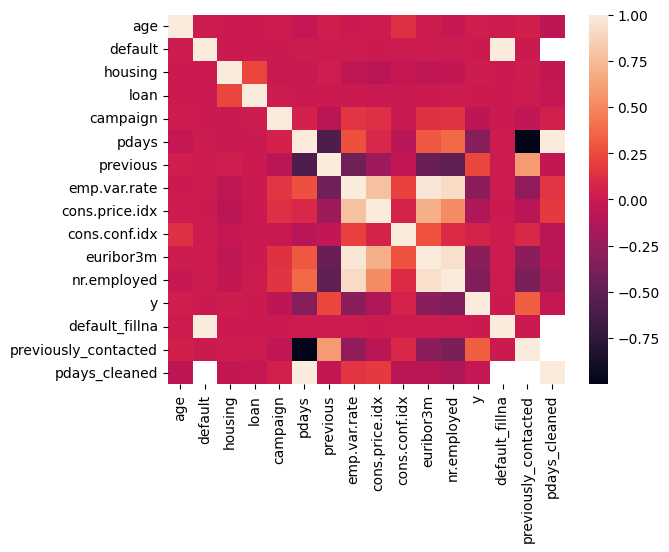

In [345]:
sns.heatmap(bank.corr(numeric_only=True))

**1. CAMPAIGN GROUP**

In [346]:
# Subscription count per category

pd.crosstab(bank["campaign_group"], bank["y"])

y,0,1
campaign_group,,
1 Contact,15342,2300
2-3 Contacts,14126,1785
4-5 Contacts,3881,369
6-10 Contacts,2357,159
10+ Contacts,842,27


In [347]:
# Subscription rate per category

pd.crosstab(bank['campaign_group'], bank['y'], normalize='index') * 100

y,0,1
campaign_group,,
1 Contact,86.962929,13.037071
2-3 Contacts,88.781346,11.218654
4-5 Contacts,91.317647,8.682353
6-10 Contacts,93.680445,6.319555
10+ Contacts,96.892980,3.107020


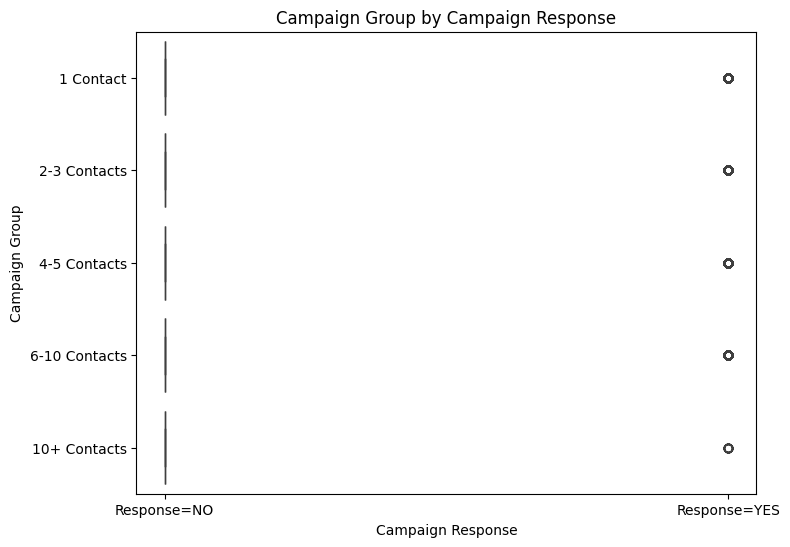

In [348]:
# Investigate the spread of values & outliers via a Boxplot

plt.figure(figsize=(8,6))

sns.boxplot(x='y', y='campaign_group', data=bank)

plt.title('Campaign Group by Campaign Response')
plt.xlabel('Campaign Response')
plt.ylabel('Campaign Group')

plt.xticks([0,1], ['Response=NO', 'Response=YES'])

plt.show()

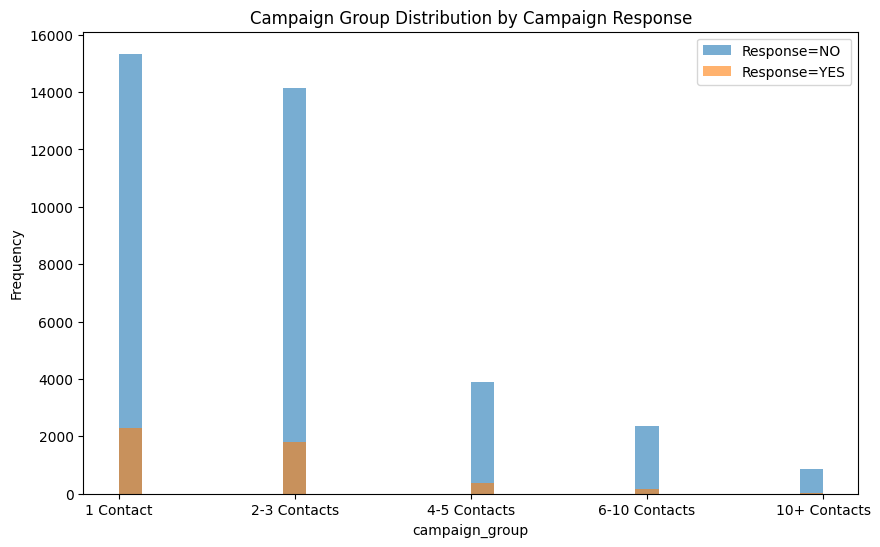

In [349]:
# Plot overall distribution via a Histogram

# Separate the groups
no_response = bank[bank['y'] == 0]['campaign_group']
yes_response = bank[bank['y'] == 1]['campaign_group']

# Plot histograms
plt.figure(figsize=(10,6))

plt.hist(no_response, bins=30, alpha=0.6, label='Response=NO')
plt.hist(yes_response, bins=30, alpha=0.6, label='Response=YES')

plt.title('Campaign Group Distribution by Campaign Response')
plt.xlabel('campaign_group')
plt.ylabel('Frequency')
plt.legend()

plt.show()

**OBSERVATIONS**</br>
Why keep? It shows a strong monotonic relationship with a positive campaign response.

**2. PREVIOUS**

In [350]:
# Subscription count per category

pd.crosstab(bank["previous"], bank["y"])

y,0,1
previous,,
0,32422,3141
1,3594,967
2,404,350
3,88,128
4,32,38
5,5,13
6,2,3
7,1,0


In [351]:
# Subscription rate per category

pd.crosstab(bank['previous'], bank['y'], normalize='index') * 100

y,0,1
previous,,
0,91.167787,8.832213
1,78.798509,21.201491
2,53.580902,46.419098
3,40.740741,59.259259
4,45.714286,54.285714
5,27.777778,72.222222
6,40.000000,60.000000
7,100.000000,0.000000


**OBSERVATIONS**</br>
Why keep? Strong relationship with conversion.</br>
This indicates that prior engagement history strongly matters.

**3. PREVIOUSLY CONTACTED**

In [352]:
# Subscription count per category

pd.crosstab(bank["previously_contacted"], bank["y"])

y,0,1
previously_contacted,,
0,36000,3673
1,548,967


In [353]:
# Subscription rate per category

pd.crosstab(bank['previously_contacted'], bank['y'], normalize='index') * 100

y,0,1
previously_contacted,,
0,90.741814,9.258186
1,36.171617,63.828383


**OBSERVATIONS**</br>
Why keep? Massive behavioral separation which can be extremely predictive.

**4. EURIBOR3M**

In [354]:
# Subscription count per category

pd.crosstab(bank["euribor3m"], bank["y"])

y,0,1
euribor3m,,
0.634,2,6
0.635,21,22
0.636,11,3
0.637,1,5
0.638,2,5
...,...,...
4.967,610,33
4.968,935,57
4.970,168,4


In [355]:
# Subscription rate per category

pd.crosstab(bank['euribor3m'], bank['y'], normalize='index') * 100

y,0,1
euribor3m,,
0.634,25.000000,75.000000
0.635,48.837209,51.162791
0.636,78.571429,21.428571
0.637,16.666667,83.333333
0.638,28.571429,71.428571
...,...,...
4.967,94.867807,5.132193
4.968,94.254032,5.745968
4.970,97.674419,2.325581


**OBSERVATIONS**</br>
Why keep? Clear macroeconomic relationship.</br>

Higher Euribor rates showed lower subscription rates and meaningful economic behavior shifts.</br>
Also, it showed the strongest macroeconomic correlation with y and strongest business interpretation.

**5. CONSUMER CONFIDENCE INDEX**

In [356]:
# Subscription count per category

pd.crosstab(bank["cons.conf.idx"], bank["y"])

y,0,1
cons.conf.idx,,
-50.8,70,58
-50.0,156,126
-49.5,111,93
-47.1,2016,442
-46.2,5270,524
-45.9,9,1
-42.7,6278,407
-42.0,3426,190
-41.8,4186,188


In [357]:
# Subscription rate per category

pd.crosstab(bank['cons.conf.idx'], bank['y'], normalize='index') * 100

y,0,1
cons.conf.idx,,
-50.8,54.687500,45.312500
-50.0,55.319149,44.680851
-49.5,54.411765,45.588235
-47.1,82.017901,17.982099
-46.2,90.956162,9.043838
-45.9,90.000000,10.000000
-42.7,93.911743,6.088257
-42.0,94.745575,5.254425
-41.8,95.701875,4.298125


**OBSERVATIONS**</br>
Why keep? Meaningful response variation across confidence environments.</br>
It captures economic sentiment dimension and it has a lower multicollinearity than other macro variables.

**6. AGE GROUP**

In [358]:
# Subscription count per category

pd.crosstab(bank["age_group"], bank["y"])

y,0,1
age_group,,
16-25,1317,349
26-35,13107,1740
36-45,11751,1093
46-55,7532,717
56-65,2512,451
65+,329,290


In [359]:
# Subscription rate per category

pd.crosstab(bank['age_group'], bank['y'], normalize='index') * 100

y,0,1
age_group,,
16-25,79.051621,20.948379
26-35,88.280461,11.719539
36-45,91.490190,8.509810
46-55,91.308037,8.691963
56-65,84.778940,15.221060
65+,53.150242,46.849758


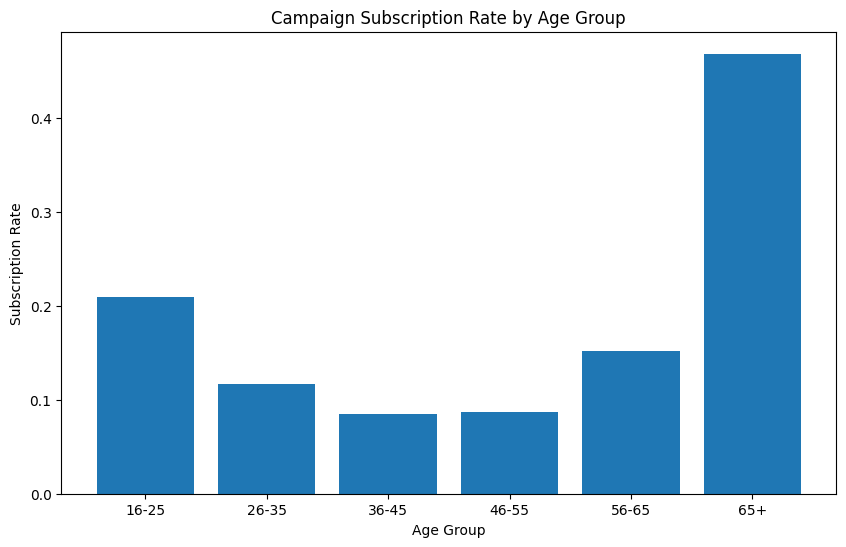

In [360]:
# Plot Conversion Rate

plt.figure(figsize=(10,6))

plt.bar(age_response['age_group'], age_response['y'])

plt.title('Campaign Subscription Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Subscription Rate')

plt.show()

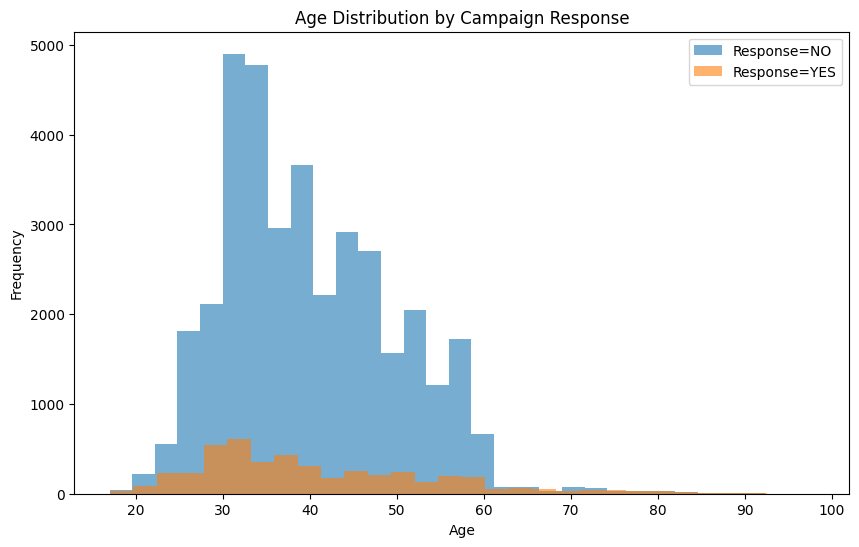

In [361]:
# “Are certain age groups more likely to subscribe to the term deposit?

# Separate the groups
no_response = bank[bank['y'] == 0]['age']
yes_response = bank[bank['y'] == 1]['age']

# Plot histograms
plt.figure(figsize=(10,6))

plt.hist(no_response, bins=30, alpha=0.6, label='Response=NO')
plt.hist(yes_response, bins=30, alpha=0.6, label='Response=YES')

plt.title('Age Distribution by Campaign Response')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()

plt.show()

**Key Insights from the Histogram:**</br>

1. Majority of customers are between ages 30–50.</br>
    The customer base is concentrated around: late 20s, 30s, 40s and early 50s.</br>
    This appears to be the bank’s primary customer demographic. </br>

2. Response=YES appear more spread into older ages and extends more visibly into ages 50–70+</br>
    Older customers may have stronger savings behavior and greater interest in lower-risk financial products such as term deposits. </br>

3. Very elderly customers exist but are relatively rare, with ages 75 to 90+ appear infrequently.</br>
    These are likely retirees, long-term customers, financially conservative savers.</br>
    These are meaningful outliers NOT data errors.

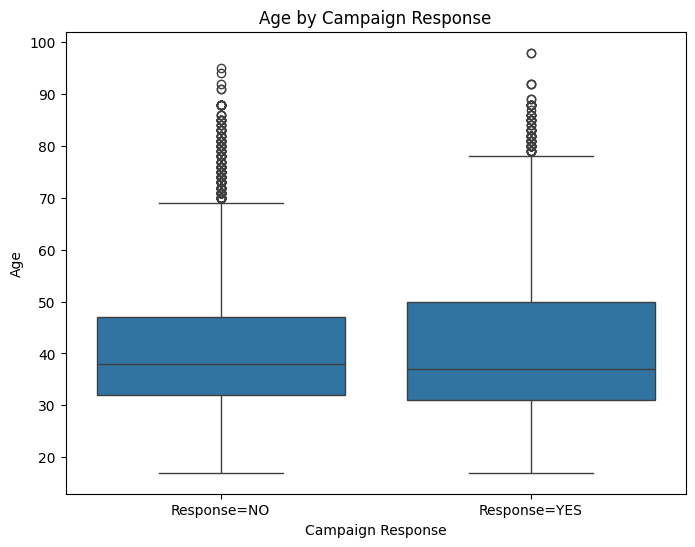

In [362]:
# Investigate the spread of values & outliers via a Boxplot

plt.figure(figsize=(8,6))

sns.boxplot(x='y', y='age', data=bank)

plt.title('Age by Campaign Response')
plt.xlabel('Campaign Response')
plt.ylabel('Age')

plt.xticks([0,1], ['Response=NO', 'Response=YES'])

plt.show()

**INSIGHTS FROM THE BOXPLOT (AGE)**
1. Median age similar for both responses, around 37-38 years old.
2. Age alone may not be a dominant predictor of subscription outcome.
3. Older customers may have slightly higher engagement with term deposit offerings.
4. Outliers exist in both groups, both in the ages 70 and above. 
5. To keep the age outliers for modeling as elderly customers are legitimate banking customers.

**OBSERVATIONS**</br>
Why keep? Age grouping revealed strong nonlinear segment behavior.</br>
It captures economic sentiment dimension and it has a lower multicollinearity than other macro variables.

<font color=green>**SUMMARY OF CORRELATION ANALYSIS AND CAMPAIGN RESPONS RATE ANALYSIS**</font>

Correlation analysis revealed that customer engagement features (campaign, previous, and previously_contacted) and macroeconomic indicators (euribor3m, emp.var.rate, and nr.employed) demonstrated the strongest relationships with subscription outcomes.</br> 
However, several macroeconomic variables exhibited high multicollinearity, particularly between euribor3m, emp.var.rate, and nr.employed. </br>
To improve model interpretability and reduce redundancy, selected features were refined by prioritizing variables with stronger predictive relevance and lower inter-feature correlation.</br>

<font color=green>**SELECTED FEATURES (NUMERICAL)**</font>
1. campaign_group: Campaign behavior
2. previous: Customer engagement history
3. previously_contacted: Customer engagement history
4. euribor3m: Economic environment
5. cons.conf.idx: Economic environment
6. age_group: Customer demographics

#### 7. Now investigate the relationship between the categorical variables and the target

First, identify which columns in the data are categorical.

The question we care about again is "how does the % of customers who bought the product vary among different jobs/education levels etc.?"

**HISTORICAL CAMPAIGN BEHAVIOR**</br>

**1. POUTCOME**


In [364]:
# Subscription count per category

pd.crosstab(bank["poutcome"], bank["y"])

y,0,1
poutcome,,
failure,3647,605
nonexistent,32422,3141
success,479,894


In [365]:
# Subscription rate per category

pd.crosstab(bank['poutcome'], bank['y'], normalize='index') * 100

y,0,1
poutcome,,
failure,85.771402,14.228598
nonexistent,91.167787,8.832213
success,34.887109,65.112891


**OBSERVATIONS**</br>
Business Interpretation: Customers who previously subscribed successfully are dramatically more likely to subscribe again.</br>
Why Keep? Huge separation in conversion rates. This is an extremely valuable behavioral signal.

**CUSTOMER DEMOGRAPHICS**

**2. JOB**

In [366]:
# Subscription count per category

pd.crosstab(bank["job_cleaned"], bank["y"])

y,0,1
job_cleaned,,
Other,293,37
admin.,9070,1352
blue-collar,8616,638
entrepreneur,1332,124
housemaid,954,106
management,2596,328
retired,1286,434
self-employed,1272,149
services,3646,323


In [367]:
# Subscription rate per category

pd.crosstab(bank['job_cleaned'], bank['y'], normalize='index') * 100

y,0,1
job_cleaned,,
Other,88.787879,11.212121
admin.,87.027442,12.972558
blue-collar,93.105684,6.894316
entrepreneur,91.483516,8.516484
housemaid,90.000000,10.000000
management,88.782490,11.217510
retired,74.767442,25.232558
self-employed,89.514426,10.485574
services,91.861930,8.138070


**OBSERVATIONS**</br>
Students and retirees are highly responsive segments while blue-collar customers are less responsive.</br>
Why Keep? Strong customer segmentation signal.

**3. MARITAL**

In [368]:
# Subscription count per category

pd.crosstab(bank["marital"], bank["y"])

y,0,1
marital,,
divorced,4136,476
married,22396,2532
single,9948,1620
unknown,68,12


In [369]:
# Subscription rate per category

pd.crosstab(bank['marital'], bank['y'], normalize='index') * 100

y,0,1
marital,,
divorced,89.679098,10.320902
married,89.842747,10.157253
single,85.995851,14.004149
unknown,85.000000,15.000000


**OBSERVATIONS**</br>
Some separation exists, but relatively modest.</br>
Optional/Lower Priority Feature. Keep initially. Feature importance analysis later can decide whether to remove it.

**4. EDUCATION**

In [370]:
# Subscription count per category

pd.crosstab(bank["education_cleaned"], bank["y"])

y,0,1
education_cleaned,,
Basic,11424,1089
Other,14,4
high.school,8484,1031
professional.course,4648,595
university.degree,10498,1670
unknown,1480,251


In [371]:
# Subscription rate per category

pd.crosstab(bank['education_cleaned'], bank['y'], normalize='index') * 100

y,0,1
education_cleaned,,
Basic,91.297051,8.702949
Other,77.777778,22.222222
high.school,89.164477,10.835523
professional.course,88.651535,11.348465
university.degree,86.275477,13.724523
unknown,85.499711,14.500289


**OBSERVATIONS**</br>
Moderate but meaningful differentiation.</br>
Why Keep? Still useful demographic signal.

**FINANCIAL OBLIGATIONS**

**5. HOUSING**

In [372]:
# Subscription count per category

pd.crosstab(bank["housing"], bank["y"])

y,0,1
housing,,
-1.0,883,107
0.0,16596,2026
1.0,19069,2507


In [373]:
# Subscription rate per category

pd.crosstab(bank['housing'], bank['y'], normalize='index') * 100

y,0,1
housing,,
-1.0,89.191919,10.808081
0.0,89.120395,10.879605
1.0,88.380608,11.619392


**OBSERVATIONS**</br>
Almost no meaningful separation.</br>
Lower Signal Feature. Can drop to simplify the model due to low predictive value.

**6. LOAN**

In [374]:
# Subscription count per category

pd.crosstab(bank["loan"], bank["y"])

y,0,1
loan,,
-1.0,883,107
0.0,30100,3850
1.0,5565,683


In [375]:
# Subscription rate per category

pd.crosstab(bank['loan'], bank['y'], normalize='index') * 100

y,0,1
loan,,
-1.0,89.191919,10.808081
0.0,88.659794,11.340206
1.0,89.068502,10.931498


**OBSERVATIONS**</br>
Virtually identical conversion rates.</br>
Lower Signal Feature. Can drop to simplify the model due to very weak signal.

**CAMPAIGN EXECUTION**

**7. CONTACT**

In [376]:
# Subscription count per category

pd.crosstab(bank["contact"], bank["y"])

y,0,1
contact,,
cellular,22291,3853
telephone,14257,787


In [377]:
# Subscription rate per category

pd.crosstab(bank['contact'], bank['y'], normalize='index') * 100

y,0,1
contact,,
cellular,85.262393,14.737607
telephone,94.768679,5.231321


**OBSERVATIONS**</br>
Cellular campaigns appear significantly more effective.</br>
Why Keep? Clear and meaningful separation.

**8. MONTH**

In [378]:
# Subscription count per category

pd.crosstab(bank["month"], bank["y"])

y,0,1
month,,
apr,2093,539
aug,5523,655
dec,93,89
jul,6525,649
jun,4759,559
mar,270,276
may,12883,886
nov,3685,416
oct,403,315


In [379]:
# Subscription rate per category

pd.crosstab(bank['month'], bank['y'], normalize='index') * 100

y,0,1
month,,
apr,79.521277,20.478723
aug,89.397863,10.602137
dec,51.098901,48.901099
jul,90.953443,9.046557
jun,89.488530,10.511470
mar,49.450549,50.549451
may,93.565255,6.434745
nov,89.856133,10.143867
oct,56.128134,43.871866


**9. DAY OF WEEK**

In [380]:
# Subscription count per category

pd.crosstab(bank["day_of_week"], bank["y"])

y,0,1
day_of_week,,
fri,6981,846
mon,7667,847
thu,7578,1045
tue,7137,953
wed,7185,949


In [381]:
# Subscription rate per category

pd.crosstab(bank['day_of_week'], bank['y'], normalize='index') * 100

y,0,1
day_of_week,,
fri,89.191261,10.808739
mon,90.051680,9.948320
thu,87.881248,12.118752
tue,88.220025,11.779975
wed,88.332924,11.667076


**OBSERVATIONS**</br>
Very small variation.</br>
Optional/Lower Priority Feature. Low-value feature. Can keep initially but may not contribute much.

<font color=green>**SUMMARY OF FURTHER EDA OF CATEGORICAL VARIABLES BASED ON THEIR CAMPAIGN RESPONSE**</font>

These variables show strong differentiation in campaign response rates across categories were retained for modeling: </br>

<font color=green>**SELECTED FEATURES (CATEGORICAL)**</br></font>
1. poutcome: Historical campaign behavior
2. month: Campaign execution
3. contact: Campaign execution
4. job_cleaned: Customer demographics
5. education_cleaned: Customer demographics
6. marital: Customer demographics

#### 8. Using the results of your EDA choose your features to put into your first predictive model

A "good" feature is one which contains *variance of the outcome*. For example, if people in all age groups bought the product at around the same %, age would **not** be a good feature, because it doesn't get us closer to separating those that bought from those that didn't.

#### <font color=green>**FEATURE LIST**</br></font>
The final feature set was selected based on business relevance, behavioral differentiation observed during exploratory data analysis, reduced redundancy, and practical applicability for predictive modeling.</br>
The selected variables collectively capture customer demographics, engagement history, campaign execution factors, and macroeconomic conditions that influence term deposit subscription behavior.

**SELECTED FEATURES (CATEGORICAL)**</br>
1. poutcome: Historical campaign behavior
2. month: Campaign execution
3. contact: Campaign execution
4. job_cleaned: Customer demographics
5. education_cleaned: Customer demographics
6. marital: Customer demographics
7. age_group: Customer demographics

**SELECTED FEATURES (NUMERICAL)**
1. campaign_group: Campaign behavior
2. previous: Customer engagement history
3. previously_contacted: Customer engagement history
4. euribor3m: Economic environment
5. cons.conf.idx: Economic environment

# <font color="red">Part 2 - our first model</font>

It's time to build your first predictive model.

#### 1. First, do any transformations required to our data
    
- If you haven't already, based on your EDA results drop any values you don't wish to use (outliers, certain categories)
- For your categorical column(s) convert the columns to a dummy (one-hot encoded) representation if you wish to use them

Once you convert the categories to dummies, drop one of the columns per category. Remember this acts as a "reference", as your "default" category. Typically we choose the category containing the most values.

**Create an independent copy of the bank dataframe**

In [383]:
bank_model = bank.copy()
bank_model

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,euribor3m,nr.employed,y,default_fillna,age_group,previously_contacted,pdays_cleaned,campaign_group,job_cleaned,education_cleaned
0,56,housemaid,married,basic.4y,0.0,0.0,0.0,telephone,may,mon,...,4.857,5191.0,0,0.0,56-65,0,<NA>,1 Contact,housemaid,Basic
1,57,services,married,high.school,NaN,0.0,0.0,telephone,may,mon,...,4.857,5191.0,0,0.0,56-65,0,<NA>,1 Contact,services,high.school
2,37,services,married,high.school,0.0,1.0,0.0,telephone,may,mon,...,4.857,5191.0,0,0.0,36-45,0,<NA>,1 Contact,services,high.school
3,40,admin.,married,basic.6y,0.0,0.0,0.0,telephone,may,mon,...,4.857,5191.0,0,0.0,36-45,0,<NA>,1 Contact,admin.,Basic
4,56,services,married,high.school,0.0,0.0,1.0,telephone,may,mon,...,4.857,5191.0,0,0.0,56-65,0,<NA>,1 Contact,services,high.school
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,0.0,1.0,0.0,cellular,nov,fri,...,1.028,4963.6,1,0.0,65+,0,<NA>,1 Contact,retired,professional.course
41184,46,blue-collar,married,professional.course,0.0,0.0,0.0,cellular,nov,fri,...,1.028,4963.6,0,0.0,46-55,0,<NA>,1 Contact,blue-collar,professional.course
41185,56,retired,married,university.degree,0.0,1.0,0.0,cellular,nov,fri,...,1.028,4963.6,0,0.0,56-65,0,<NA>,2-3 Contacts,retired,university.degree
41186,44,technician,married,professional.course,0.0,0.0,0.0,cellular,nov,fri,...,1.028,4963.6,1,0.0,36-45,0,<NA>,1 Contact,technician,professional.course


In [384]:
# View the list of columns

bank_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   age                   41188 non-null  int64   
 1   job                   41188 non-null  str     
 2   marital               41188 non-null  str     
 3   education             41188 non-null  str     
 4   default               32591 non-null  float64 
 5   housing               41188 non-null  float64 
 6   loan                  41188 non-null  float64 
 7   contact               41188 non-null  str     
 8   month                 41188 non-null  str     
 9   day_of_week           41188 non-null  str     
 10  campaign              41188 non-null  int64   
 11  pdays                 41188 non-null  int64   
 12  previous              41188 non-null  int64   
 13  poutcome              41188 non-null  str     
 14  emp.var.rate          41188 non-null  float64 
 15  cons.price.id

**Drop columns not needed for the model: 13 columns**

In [385]:
bank_model = bank_model.drop(columns=['age', 'job', 'education', 'default', 'housing', 'loan', 'day_of_week', 'campaign', 'pdays', 'emp.var.rate', 'cons.price.idx', 'nr.employed', 'pdays_cleaned'], errors='ignore')

bank_model

,marital,contact,month,previous,poutcome,cons.conf.idx,euribor3m,y,default_fillna,age_group,previously_contacted,campaign_group,job_cleaned,education_cleaned
0,married,telephone,may,0,nonexistent,-36.4,4.857,0,0.0,56-65,0,1 Contact,housemaid,Basic
1,married,telephone,may,0,nonexistent,-36.4,4.857,0,0.0,56-65,0,1 Contact,services,high.school
2,married,telephone,may,0,nonexistent,-36.4,4.857,0,0.0,36-45,0,1 Contact,services,high.school
3,married,telephone,may,0,nonexistent,-36.4,4.857,0,0.0,36-45,0,1 Contact,admin.,Basic
4,married,telephone,may,0,nonexistent,-36.4,4.857,0,0.0,56-65,0,1 Contact,services,high.school
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,married,cellular,nov,0,nonexistent,-50.8,1.028,1,0.0,65+,0,1 Contact,retired,professional.course
41184,married,cellular,nov,0,nonexistent,-50.8,1.028,0,0.0,46-55,0,1 Contact,blue-collar,professional.course
41185,married,cellular,nov,0,nonexistent,-50.8,1.028,0,0.0,56-65,0,2-3 Contacts,retired,university.degree
41186,married,cellular,nov,0,nonexistent,-50.8,1.028,1,0.0,36-45,0,1 Contact,technician,professional.course


In [386]:
# View the list of columns

bank_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   marital               41188 non-null  str     
 1   contact               41188 non-null  str     
 2   month                 41188 non-null  str     
 3   previous              41188 non-null  int64   
 4   poutcome              41188 non-null  str     
 5   cons.conf.idx         41188 non-null  float64 
 6   euribor3m             41188 non-null  float64 
 7   y                     41188 non-null  int64   
 8   default_fillna        41188 non-null  float64 
 9   age_group             41188 non-null  category
 10  previously_contacted  41188 non-null  int64   
 11  campaign_group        41188 non-null  category
 12  job_cleaned           41188 non-null  str     
 13  education_cleaned     41188 non-null  str     
dtypes: category(2), float64(3), int64(3), str(6)
memory usage: 5.8 MB

In [387]:
# View summary statistics for categorical/text columns

bank_model.describe()

,previous,cons.conf.idx,euribor3m,y,default_fillna,previously_contacted
count,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,0.172963,-40.502600,3.621291,0.112654,0.000073,0.036783
std,0.494901,4.628198,1.734447,0.316173,0.008534,0.188230
min,0.000000,-50.800000,0.634000,0.000000,0.000000,0.000000
25%,0.000000,-42.700000,1.344000,0.000000,0.000000,0.000000
50%,0.000000,-41.800000,4.857000,0.000000,0.000000,0.000000
75%,0.000000,-36.400000,4.961000,0.000000,0.000000,0.000000
max,7.000000,-26.900000,5.045000,1.000000,1.000000,1.000000


In [388]:
bank_model.describe(include=['object', 'string'])

,marital,contact,month,poutcome,job_cleaned,education_cleaned
count,41188,41188,41188,41188,41188,41188
unique,4,2,10,3,12,6
top,married,cellular,may,nonexistent,admin.,Basic
freq,24928,26144,13769,35563,10422,12513


**Apply One-Hot Encoding and drop the category with most values (the most common category)**

Categorical variables are one-hot encoded with the most frequent category used as the reference baseline to improve interpretability and coefficient stability in downstream modeling.

In [389]:
# List all the categorical features
categorical_features = [
    'poutcome',
    'month',
    'contact',
    'job_cleaned',
    'education_cleaned',
    'marital',
    'age_group',
    'campaign_group'
]

for col in categorical_features:
    
    # Get categories ordered by frequency
    ordered_categories = (
        bank_model[col]
        .value_counts()
        .index
        .tolist()
    )
    
    # Convert to categorical type
    bank_model[col] = pd.Categorical(
        bank_model[col],
        categories=ordered_categories,
        ordered=True
    )

# One-hot encode
bank_encoded = pd.get_dummies(
    bank_model,
    columns=categorical_features,
    drop_first=True
)

In [390]:
bank_encoded

,previous,cons.conf.idx,euribor3m,y,default_fillna,previously_contacted,poutcome_failure,poutcome_success,month_jul,month_aug,...,marital_unknown,age_group_36-45,age_group_46-55,age_group_56-65,age_group_16-25,age_group_65+,campaign_group_2-3 Contacts,campaign_group_4-5 Contacts,campaign_group_6-10 Contacts,campaign_group_10+ Contacts
0,0,-36.4,4.857,0,0.0,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,0,-36.4,4.857,0,0.0,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,0,-36.4,4.857,0,0.0,0,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
3,0,-36.4,4.857,0,0.0,0,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
4,0,-36.4,4.857,0,0.0,0,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,0,-50.8,1.028,1,0.0,0,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
41184,0,-50.8,1.028,0,0.0,0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
41185,0,-50.8,1.028,0,0.0,0,False,False,False,False,...,False,False,False,True,False,False,True,False,False,False
41186,0,-50.8,1.028,1,0.0,0,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [391]:
bank_encoded.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 46 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   previous                               41188 non-null  int64  
 1   cons.conf.idx                          41188 non-null  float64
 2   euribor3m                              41188 non-null  float64
 3   y                                      41188 non-null  int64  
 4   default_fillna                         41188 non-null  float64
 5   previously_contacted                   41188 non-null  int64  
 6   poutcome_failure                       41188 non-null  bool   
 7   poutcome_success                       41188 non-null  bool   
 8   month_jul                              41188 non-null  bool   
 9   month_aug                              41188 non-null  bool   
 10  month_jun                              41188 non-null  bool   
 11  month_nov    

#### 2. Create the necessary `X_train`, `X_test`, `y_train` and `y_test` variables using the features you chose above.

Make sure `X_train` and `X_test` only include the features you chose (including the dummy variables for categorical features).

<font color=green>**MODEL 1: STANDARD LOGISTIC REGRESSION**</font>

Why Logistic Regression?
1. Works well for binary classification: Target y is binary (0, 1)
2. Highly interpretable: Easy to explain feature impact
3. Your target y is binary: Your target y is binary
4. Good for business presentations: Coefficients are explainable
5. Helps identify influential variables: Helps identify influential variables

**Step 1: Define X and y**

In [395]:
X = bank_encoded.drop('y', axis=1)
y = bank_encoded['y']

**Step 2: Train/Test Split**</br>
Stratified train-test splitting was applied to preserve the original class distribution of the target variable across both training and testing datasets, </br>
ensuring reliable model training and evaluation. This is because the dataset is imbalanced whereby the y variable has an 89-11 split of 0 and 1 values.</br>

In [ ]:
# Split the data into Train and Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=27,
    stratify=y #Key parameter
)

In [437]:
y_test.shape

(8238,)

In [432]:
X_test.shape

(8238, 45)

In [439]:
y_train.shape

(32950,)

In [440]:
X_train.shape

(32950, 45)

**Step 3: Verify stratification**

In [ ]:
#Distribution of the target variable, y

y.value_counts(normalize=True)

y
0    0.887346
1    0.112654
Name: proportion, dtype: float64

In [ ]:
#Distribution of y_train

y_train.value_counts(normalize=True)

y
0    0.887344
1    0.112656
Name: proportion, dtype: float64

In [401]:
#Distribution of y_test

y_test.value_counts(normalize=True)

y
0    0.887351
1    0.112649
Name: proportion, dtype: float64

**Step 4: Scale Numerical Variables**

In [ ]:
# Scale numerical variables
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# View the data
X_train_scaled

array([[ 1.66375036,  1.96287982, -1.58151435, ..., -0.34014861,
        -0.25413768, -0.1474351 ],
       [-0.34727584, -1.42491176, -1.2366666 , ..., -0.34014861,
        -0.25413768, -0.1474351 ],
       [-0.34727584,  0.8839653 ,  0.71247288, ..., -0.34014861,
        -0.25413768, -0.1474351 ],
       ...,
       [-0.34727584, -1.23070714, -1.30875016, ..., -0.34014861,
         3.93487505, -0.1474351 ],
       [ 1.66375036, -1.23070714, -1.32432021, ..., -0.34014861,
        -0.25413768, -0.1474351 ],
       [-0.34727584, -0.28126237,  0.77475308, ..., -0.34014861,
        -0.25413768, -0.1474351 ]], shape=(32950, 45))

In [ ]:
# View the data
X_test_scaled

array([[-0.34727584,  0.8839653 ,  0.71074287, ...,  2.93989144,
        -0.25413768, -0.1474351 ],
       [-0.34727584,  0.8839653 ,  0.71189621, ...,  2.93989144,
        -0.25413768, -0.1474351 ],
       [-0.34727584,  0.8839653 ,  0.71131954, ...,  2.93989144,
        -0.25413768, -0.1474351 ],
       ...,
       [-0.34727584, -1.23070714, -1.31451684, ..., -0.34014861,
        -0.25413768, -0.1474351 ],
       [-0.34727584,  0.94870017,  0.7724464 , ..., -0.34014861,
        -0.25413768, -0.1474351 ],
       [-0.34727584, -1.23070714, -1.33239357, ..., -0.34014861,
        -0.25413768, -0.1474351 ]], shape=(8238, 45))

#### 3. Train a classifier on the training data

**Step 5: Train the data using Standard Logistic Regression**

In [409]:
# Train the data using Logistic Regression

log_model = LogisticRegression(
    max_iter=1000,
    random_state=27
)

log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",27
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

**Step 6: Generate Predictions**

In [417]:
y_pred = log_model.predict(X_test_scaled)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(8238,))

#### 4. Now dig into the evaluation of your first model
    
First of all, get the basic accuracy score and compare this against a baseline.
    
The baseline is "predict everything is the majority class" (in this case always predict no purchase). Our accuracy score should be higher than the % of the majority class.

**Step 7: Evaluate model using a Classification Report**

In [506]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7310
           1       0.61      0.21      0.31       928

    accuracy                           0.90      8238
   macro avg       0.76      0.60      0.63      8238
weighted avg       0.87      0.90      0.87      8238



**Step 8: Evaluate model using a Confusion Matrix**

In [507]:
# Confusion Matrix
confusion_matrix_lr = confusion_matrix(y_test, y_pred)

confusion_matrix_lr

array([[7185,  125],
       [ 733,  195]])

#### 5. Now build and inspect the confusion matrix

- What does a false positive mean in this task? What does a false negative mean?
- Which do you have more of?
- What is the cost associated with these?

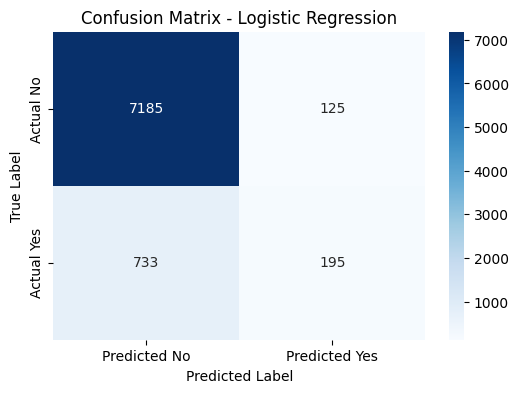

In [424]:
# Visualize the Confusion Matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

<font color=green>**UNDERSTANDING THE RESULTS USING THE CONFUSION MATRIX**</font></br></br>
**1. TRUE NEGATIVE (TN)**</br>
    - Value: 7185
    - Model correctly predicted that customer will NOT subscribe

**2. TRUE POSITIVE (TP)**</br>
    - Value: 195
    - Model correctly predicted that customer WILL subscribe

**3. FALSE POSITIVE (FP)**</br>
    - Value: 125
    - Model predicted that customer WILL subscribe BUT actual result customer did NOT subscribe
    - In business terms: The bank targeted a customer expecting them to subscribe, but the customer ultimately did not subscribe.
    - Business Cost of False Positives: 
        - unnecessary call center effort
        - marketing cost
        - wasted campaign resources
        - reduced operational efficiency

**4. FALSE NEGATIVE (FN)**</br>
    - Value: 733
    - Model predicted customer will NOT subscribe BUT actual result customer WOULD HAVE subscribed
    - The bank failed to identify a customer who was actually likely to subscribe. The bank may not contact them, miss potential revenue and lose conversion opportunities.
    - Business Cost of False Negatives:
        - lost term deposit revenue
        - missed sales opportunities
        - reduced campaign effectiveness
        - lower customer acquisition </br>
Therefore, the bank lose actual customers.


**WHICH DO I HAVE MORE OF?**</br>
I have more FALSE NEGATIVES.
My current model is conservative and biased toward predicting “No”.</br>

**WHY THIS HAPPENS?**</br>
The dataset is imbalanced.</br>
No = 89%</br>
Yes = 11%</br>

The model learns that predicting No most of the time gives high accuracy.</br>
That’s why Accuracy = 90% but Recall for class 1 = only 21%.



<font color=green>**UNDERSTANDING THE RESULTS USING THE CLASSIFICATION MATRIX**</font></br>

Metric: Class 1</br>
Precision: 0.61</br>
Recall: 0.21</br>
F1-score: 0.31</br>


**Recall = 21%**</br>
This means that the model only identified 21% of actual subscribers.</br>
This explains the large number of false negatives.</br>

**Business Interpretation**</br>
The model avoids contacting unlikely customers BUT misses many potential subscribers.

#### 6. Inspect the errors in more detail

Beyond summary accuracy metrics, you want to know how your model performed across various customers.

Your analysis should **not** be limited to the columns you used as features. If you used age for example, consider looking at how errors are distributed among marital status for example.

What you want to know is: ***is our model more/less accurate for different types of customers?***

An idea for this is to:
- create a column that denotes whether a customer was correctly predicted as wanting to purchase the product or not
- look at the distribution this column (i.e. the accuracy) among different categories (either age, job, education level etc.)

**STEP 1: Create Evaluation DataFrame**

In [457]:
# Create evaluation dataframe using ORIGINAL fields, but only TEST rows
evaluate_model = bank_model.loc[X_test.index].copy()

evaluate_model

,marital,contact,month,previous,poutcome,cons.conf.idx,euribor3m,y,default_fillna,age_group,previously_contacted,campaign_group,job_cleaned,education_cleaned
1073,married,telephone,may,0,nonexistent,-36.4,4.856,0,0.0,46-55,0,4-5 Contacts,blue-collar,Basic
4102,single,telephone,may,0,nonexistent,-36.4,4.858,0,0.0,36-45,0,4-5 Contacts,blue-collar,Basic
6548,single,telephone,may,0,nonexistent,-36.4,4.857,0,0.0,16-25,0,4-5 Contacts,management,university.degree
4417,married,telephone,may,0,nonexistent,-36.4,4.856,0,0.0,36-45,0,1 Contact,services,high.school
11241,married,telephone,jun,0,nonexistent,-41.8,4.961,0,0.0,36-45,0,1 Contact,admin.,high.school
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,single,telephone,may,0,nonexistent,-36.4,4.857,0,0.0,36-45,0,2-3 Contacts,technician,professional.course
17268,married,cellular,jul,0,nonexistent,-42.7,4.962,0,0.0,36-45,0,2-3 Contacts,blue-collar,Basic
30683,married,cellular,may,0,nonexistent,-46.2,1.344,0,0.0,26-35,0,1 Contact,blue-collar,Basic
21549,single,cellular,aug,0,nonexistent,-36.1,4.963,0,0.0,36-45,0,1 Contact,admin.,university.degree


In [458]:
# Add actual and predicted values

evaluate_model['actual'] = y_test.values
evaluate_model['predicted'] = y_pred

evaluate_model

,marital,contact,month,previous,poutcome,cons.conf.idx,euribor3m,y,default_fillna,age_group,previously_contacted,campaign_group,job_cleaned,education_cleaned,actual,predicted
1073,married,telephone,may,0,nonexistent,-36.4,4.856,0,0.0,46-55,0,4-5 Contacts,blue-collar,Basic,0,0
4102,single,telephone,may,0,nonexistent,-36.4,4.858,0,0.0,36-45,0,4-5 Contacts,blue-collar,Basic,0,0
6548,single,telephone,may,0,nonexistent,-36.4,4.857,0,0.0,16-25,0,4-5 Contacts,management,university.degree,0,0
4417,married,telephone,may,0,nonexistent,-36.4,4.856,0,0.0,36-45,0,1 Contact,services,high.school,0,0
11241,married,telephone,jun,0,nonexistent,-41.8,4.961,0,0.0,36-45,0,1 Contact,admin.,high.school,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,single,telephone,may,0,nonexistent,-36.4,4.857,0,0.0,36-45,0,2-3 Contacts,technician,professional.course,0,0
17268,married,cellular,jul,0,nonexistent,-42.7,4.962,0,0.0,36-45,0,2-3 Contacts,blue-collar,Basic,0,0
30683,married,cellular,may,0,nonexistent,-46.2,1.344,0,0.0,26-35,0,1 Contact,blue-collar,Basic,0,0
21549,single,cellular,aug,0,nonexistent,-36.1,4.963,0,0.0,36-45,0,1 Contact,admin.,university.degree,0,0


**STEP 2: Create Correct Prediction Column**

In [ ]:
# Create Correct Prediction Column

evaluate_model['correct_prediction'] = (
    evaluate_model['actual'] == evaluate_model['predicted']
)

evaluate_model

,marital,contact,month,previous,poutcome,cons.conf.idx,euribor3m,y,default_fillna,age_group,previously_contacted,campaign_group,job_cleaned,education_cleaned,actual,predicted,correct_prediction
1073,married,telephone,may,0,nonexistent,-36.4,4.856,0,0.0,46-55,0,4-5 Contacts,blue-collar,Basic,0,0,True
4102,single,telephone,may,0,nonexistent,-36.4,4.858,0,0.0,36-45,0,4-5 Contacts,blue-collar,Basic,0,0,True
6548,single,telephone,may,0,nonexistent,-36.4,4.857,0,0.0,16-25,0,4-5 Contacts,management,university.degree,0,0,True
4417,married,telephone,may,0,nonexistent,-36.4,4.856,0,0.0,36-45,0,1 Contact,services,high.school,0,0,True
11241,married,telephone,jun,0,nonexistent,-41.8,4.961,0,0.0,36-45,0,1 Contact,admin.,high.school,0,0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,single,telephone,may,0,nonexistent,-36.4,4.857,0,0.0,36-45,0,2-3 Contacts,technician,professional.course,0,0,True
17268,married,cellular,jul,0,nonexistent,-42.7,4.962,0,0.0,36-45,0,2-3 Contacts,blue-collar,Basic,0,0,True
30683,married,cellular,may,0,nonexistent,-46.2,1.344,0,0.0,26-35,0,1 Contact,blue-collar,Basic,0,0,True
21549,single,cellular,aug,0,nonexistent,-36.1,4.963,0,0.0,36-45,0,1 Contact,admin.,university.degree,0,0,True


**STEP 3: Create Error Type Column**

In [470]:
# Create Error Type Column

evaluate_model['error_type'] = np.where(
    (evaluate_model['actual'] == 1) & (evaluate_model['predicted'] == 0),
    'False Negative',
    
    np.where(
        (evaluate_model['actual'] == 0) & (evaluate_model['predicted'] == 1),
        'False Positive',
        
        np.where(
            (evaluate_model['actual'] == 1) & (evaluate_model['predicted'] == 1),
            'True Positive',
            'True Negative'
        )
    )
)

evaluate_model

,marital,contact,month,previous,poutcome,cons.conf.idx,euribor3m,y,default_fillna,age_group,previously_contacted,campaign_group,job_cleaned,education_cleaned,actual,predicted,correct_prediction,error_type
1073,married,telephone,may,0,nonexistent,-36.4,4.856,0,0.0,46-55,0,4-5 Contacts,blue-collar,Basic,0,0,True,True Negative
4102,single,telephone,may,0,nonexistent,-36.4,4.858,0,0.0,36-45,0,4-5 Contacts,blue-collar,Basic,0,0,True,True Negative
6548,single,telephone,may,0,nonexistent,-36.4,4.857,0,0.0,16-25,0,4-5 Contacts,management,university.degree,0,0,True,True Negative
4417,married,telephone,may,0,nonexistent,-36.4,4.856,0,0.0,36-45,0,1 Contact,services,high.school,0,0,True,True Negative
11241,married,telephone,jun,0,nonexistent,-41.8,4.961,0,0.0,36-45,0,1 Contact,admin.,high.school,0,0,True,True Negative
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,single,telephone,may,0,nonexistent,-36.4,4.857,0,0.0,36-45,0,2-3 Contacts,technician,professional.course,0,0,True,True Negative
17268,married,cellular,jul,0,nonexistent,-42.7,4.962,0,0.0,36-45,0,2-3 Contacts,blue-collar,Basic,0,0,True,True Negative
30683,married,cellular,may,0,nonexistent,-46.2,1.344,0,0.0,26-35,0,1 Contact,blue-collar,Basic,0,0,True,True Negative
21549,single,cellular,aug,0,nonexistent,-36.1,4.963,0,0.0,36-45,0,1 Contact,admin.,university.degree,0,0,True,True Negative


**STEP 4: Analyze Errors by Customer Segments**

- Step 4A: Error Analysis</br>
- Step 4B: Analyze False Negatives</br>
    Rationale: In marketing, missed subscribers are usually the highest business cost.

In [461]:
evaluate_model.info()

<class 'pandas.DataFrame'>
Index: 8238 entries, 1073 to 32215
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   marital               8238 non-null   category
 1   contact               8238 non-null   category
 2   month                 8238 non-null   category
 3   previous              8238 non-null   int64   
 4   poutcome              8238 non-null   category
 5   cons.conf.idx         8238 non-null   float64 
 6   euribor3m             8238 non-null   float64 
 7   y                     8238 non-null   int64   
 8   default_fillna        8238 non-null   float64 
 9   age_group             8238 non-null   category
 10  previously_contacted  8238 non-null   int64   
 11  campaign_group        8238 non-null   category
 12  job_cleaned           8238 non-null   category
 13  education_cleaned     8238 non-null   category
 14  actual                8238 non-null   int64   
 15  predicted       

**1. JOB**

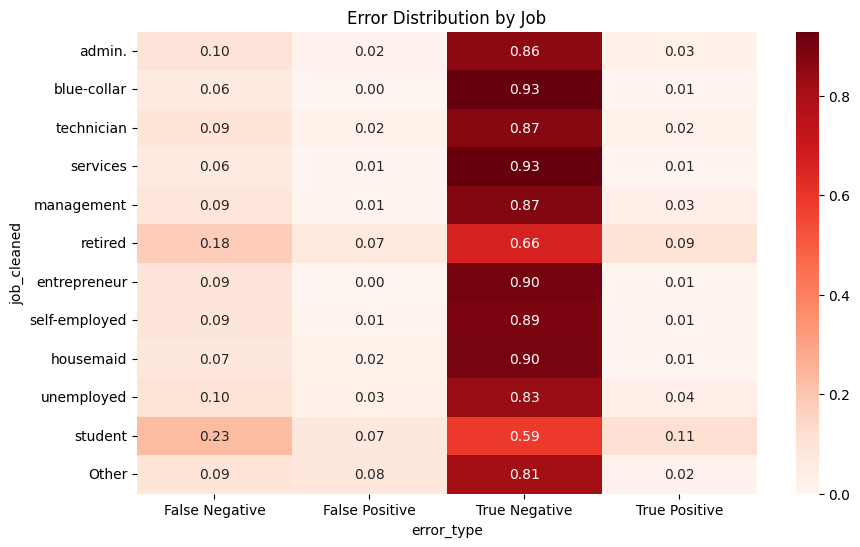

In [478]:
# Error Analysis

error_analysis = pd.crosstab(
    evaluate_model['job_cleaned'],
    evaluate_model['error_type'],
    normalize='index'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    error_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('Error Distribution by Job')
plt.show()

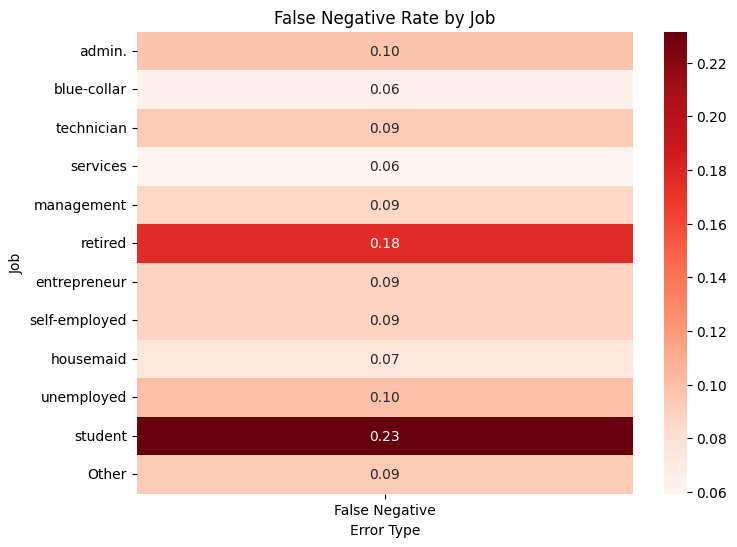

In [ ]:
# Analyze False Negatives
fn_analysis = error_analysis[['False Negative']]

plt.figure(figsize=(8,6))

sns.heatmap(
    fn_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('False Negative Rate by Job')
plt.xlabel('Error Type')
plt.ylabel('Job')

plt.show()


**OBSERVATIONS**
- Students Have the Highest False Negative Rate with 23.2%.
- The model frequently misses students who would actually subscribe.
- Possible reasons:
    - students behave differently from dominant customer groups
    - fewer student records in training data and the original dataset (875 records only which is only 2% of the population)
    - nonlinear behaviors not captured well by Logistic Regression
- Business Impact: The bank may be under-targeting younger/student customers and missing future high-value customers
- What can be done? Plan student-targeted campaigns and have a separate segmentation strategy

**2. MARITAL STATUS**

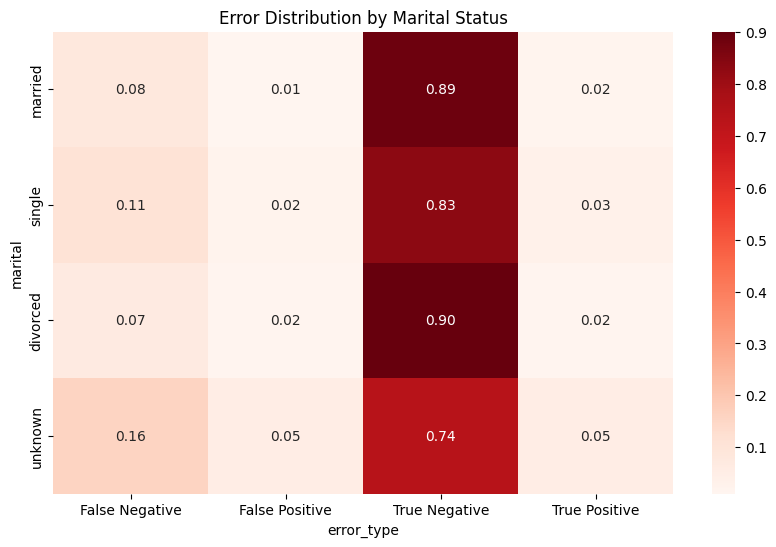

In [482]:
# Error Analysis

error_analysis = pd.crosstab(
    evaluate_model['marital'],
    evaluate_model['error_type'],
    normalize='index'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    error_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('Error Distribution by Marital Status')
plt.show()

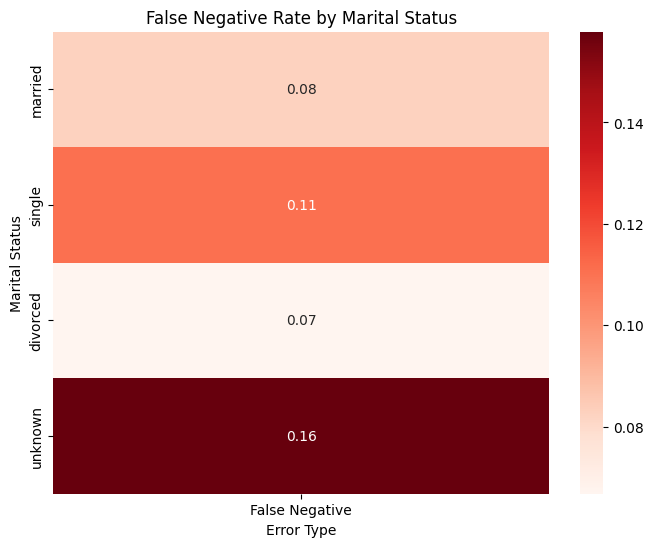

In [483]:
# Analyze False Negatives

fn_analysis = error_analysis[['False Negative']]

plt.figure(figsize=(8,6))

sns.heatmap(
    fn_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('False Negative Rate by Marital Status')
plt.xlabel('Error Type')
plt.ylabel('Marital Status')

plt.show()

**OBSERVATIONS**
1. Customers with unknown marital status showed the highest false negative rate (~16%), reinforcing the negative impact of incomplete customer information on predictive performance.
2. Single customers had higher false negatives (~11%) than married or divorced customers, suggesting more variable financial or subscription behavior.
3. Divorced customers had the lowest false negative rate (~7%), indicating the model performs relatively well for this segment.

**3. EDUCATION**

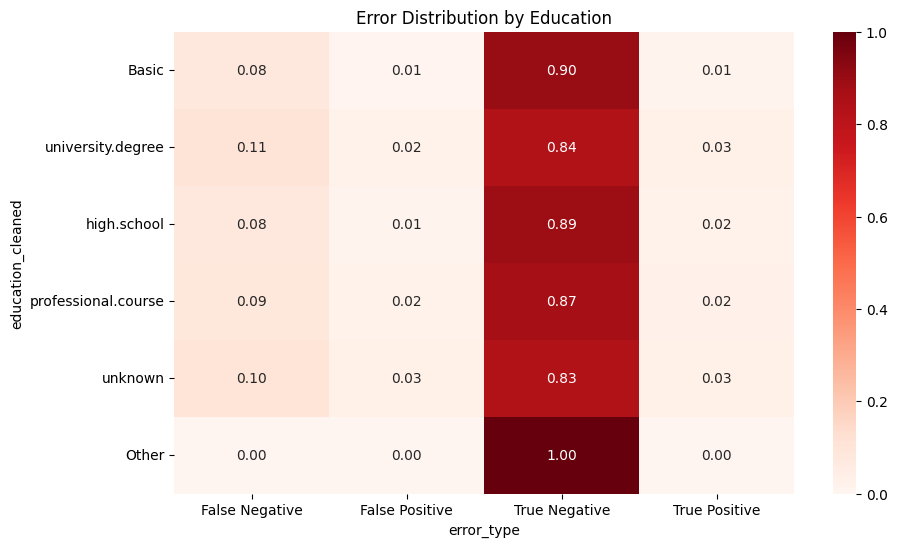

In [484]:
# Error Analysis

error_analysis = pd.crosstab(
    evaluate_model['education_cleaned'],
    evaluate_model['error_type'],
    normalize='index'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    error_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('Error Distribution by Education')
plt.show()

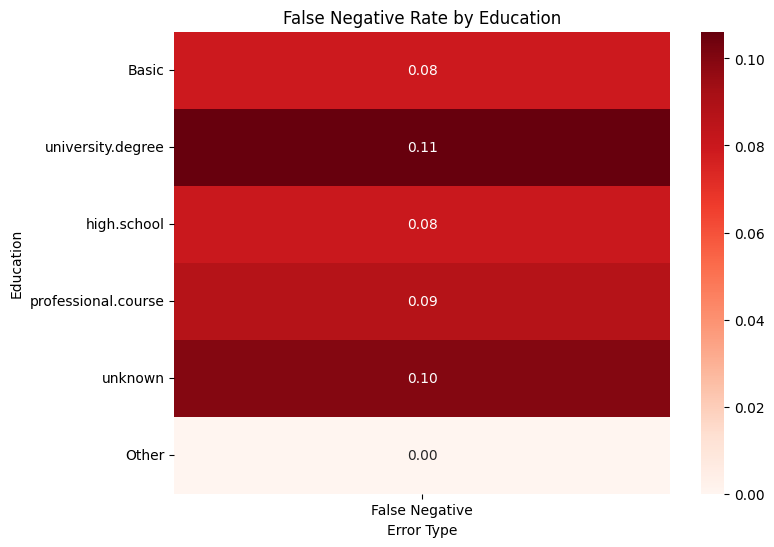

In [485]:
# Analyze False Negatives

fn_analysis = error_analysis[['False Negative']]

plt.figure(figsize=(8,6))

sns.heatmap(
    fn_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('False Negative Rate by Education')
plt.xlabel('Error Type')
plt.ylabel('Education')

plt.show()

**OBSERVATIONS**
1. Customers with university degrees had the highest false negative rate (~11%), suggesting highly educated customers may behave differently from the broader population.
2. Customers with unknown education levels also showed elevated false negatives (~10%), highlighting the impact of missing or incomplete demographic information on model performance.
3. Customers with basic or high school education had relatively lower false negative rates (~8%), indicating more stable behavioral patterns within these segments.

**4. AGE GROUP**

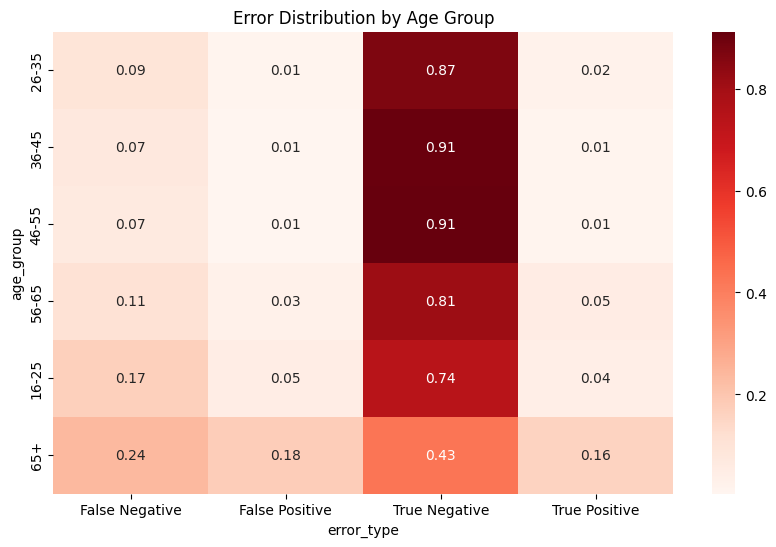

In [486]:
# Error Analysis

error_analysis = pd.crosstab(
    evaluate_model['age_group'],
    evaluate_model['error_type'],
    normalize='index'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    error_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('Error Distribution by Age Group')
plt.show()

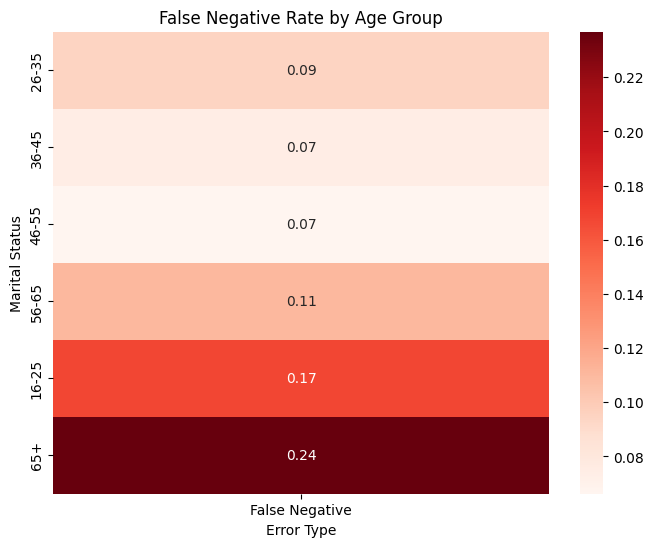

In [487]:
# Analyze False Negatives

fn_analysis = error_analysis[['False Negative']]

plt.figure(figsize=(8,6))

sns.heatmap(
    fn_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('False Negative Rate by Age Group')
plt.xlabel('Error Type')
plt.ylabel('Marital Status')

plt.show()

**OBSERVATIONS**
1. Customers aged 65+ had the highest false negative rate (~24%), indicating the model struggles substantially to identify subscribing senior customers.
2. The 16–25 age group had relatively high false negatives (~17%), suggesting younger customers may exhibit less consistent behavioral patterns.
3. Customers aged 36–55 had the lowest false negative rates (~7%), indicating the model performs most consistently for the dominant middle-aged customer segment.

**5. MONTH**

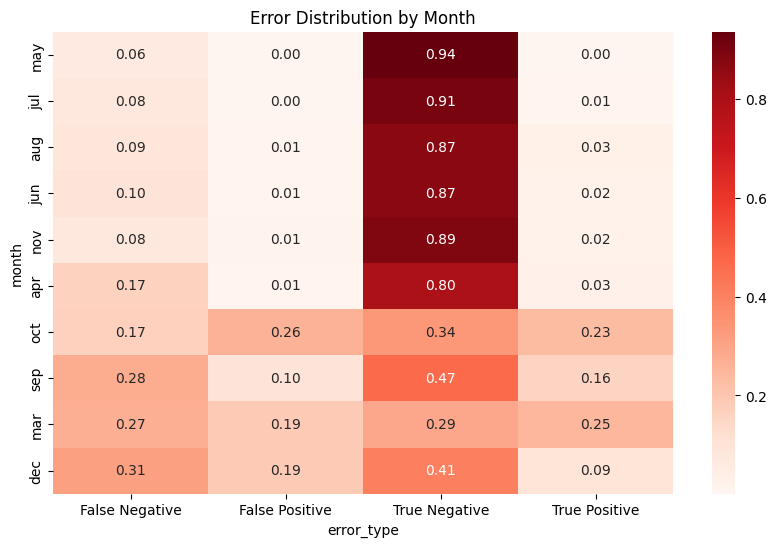

In [488]:
# Error Analysis

error_analysis = pd.crosstab(
    evaluate_model['month'],
    evaluate_model['error_type'],
    normalize='index'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    error_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('Error Distribution by Month')
plt.show()

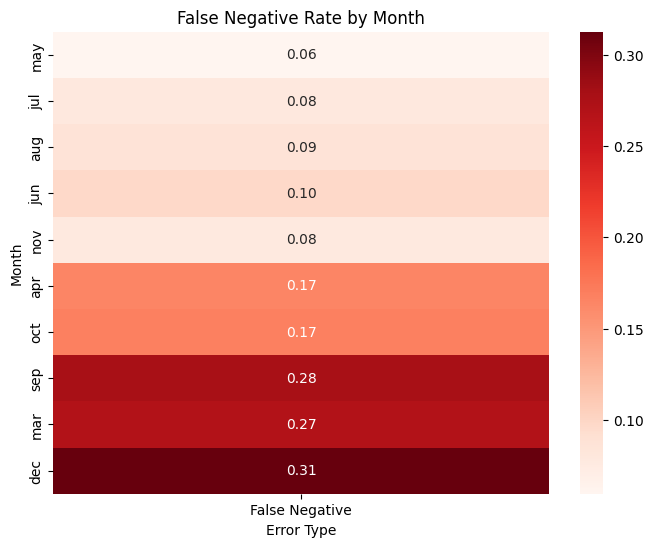

In [490]:
# Analyze False Negatives

fn_analysis = error_analysis[['False Negative']]

plt.figure(figsize=(8,6))

sns.heatmap(
    fn_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('False Negative Rate by Month')
plt.xlabel('Error Type')
plt.ylabel('Month')

plt.show()

**OBSERVATIONS**
1. The model showed extremely high false negative rates during December (~31%), September (~28%), and March (~27%), meaning many actual subscribers were missed during these months.
2. Months such as May, July, August, and November showed relatively low false negative rates (~6–9%), suggesting more stable and predictable customer response patterns.
3. The sharp variation across months indicates strong seasonality in campaign performance, implying customer subscription behavior changes significantly throughout the year.


**6. CONTACT**

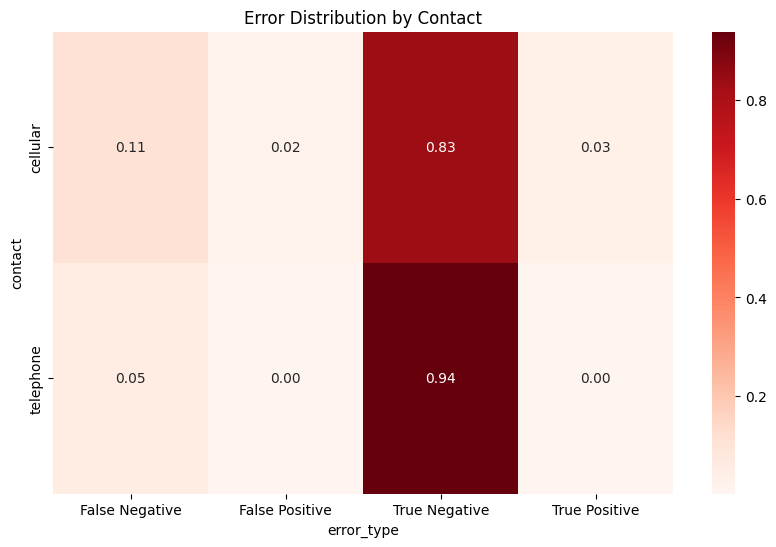

In [491]:
# Error Analysis

error_analysis = pd.crosstab(
    evaluate_model['contact'],
    evaluate_model['error_type'],
    normalize='index'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    error_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('Error Distribution by Contact')
plt.show()

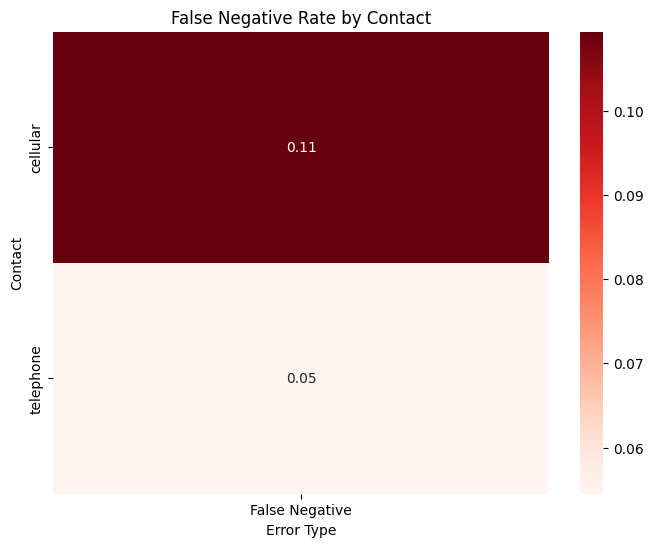

In [492]:
# Analyze False Negatives

fn_analysis = error_analysis[['False Negative']]

plt.figure(figsize=(8,6))

sns.heatmap(
    fn_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('False Negative Rate by Contact')
plt.xlabel('Error Type')
plt.ylabel('Contact')

plt.show()

**OBSERVATIONS**
1. Customers contacted through cellular channels had a higher false negative rate (~11%) compared to telephone contacts (~5%), indicating the model misses more potential subscribers in cellular campaigns.
2. The lower false negative rate for telephone contacts suggests these interactions may involve more stable or predictable customer behavior.
3. The substantial difference between contact methods indicates that campaign channel selection influences not only customer response but also model predictability.

**7. POUTCOME**

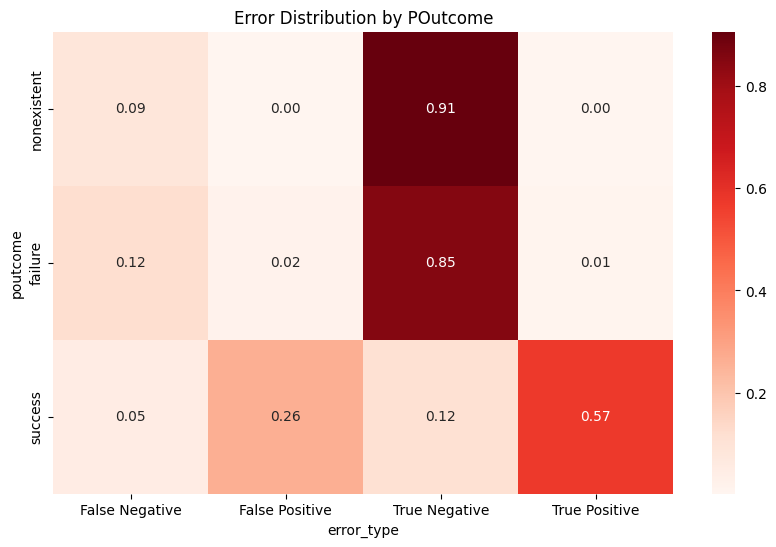

In [493]:
# Error Analysis

error_analysis = pd.crosstab(
    evaluate_model['poutcome'],
    evaluate_model['error_type'],
    normalize='index'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    error_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('Error Distribution by POutcome')
plt.show()

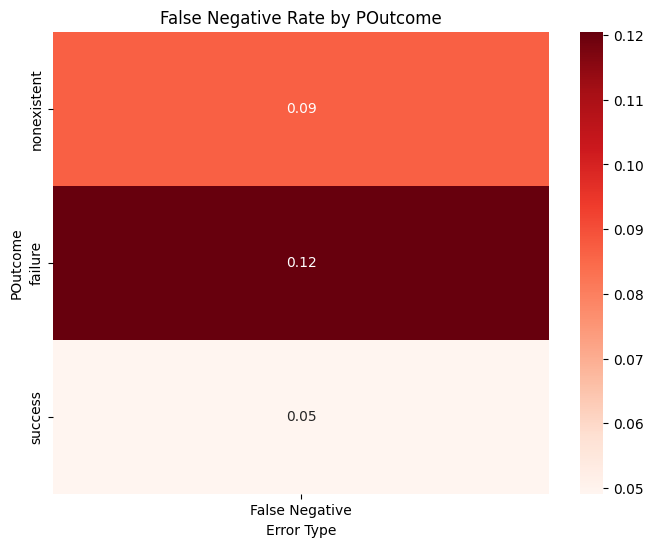

In [494]:
# Analyze False Negatives

fn_analysis = error_analysis[['False Negative']]

plt.figure(figsize=(8,6))

sns.heatmap(
    fn_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('False Negative Rate by POutcome')
plt.xlabel('Error Type')
plt.ylabel('POutcome')

plt.show()

**OBSERVATIONS**
1. Customers with a previous successful campaign outcome had the lowest false negative rate (~5%), showing that historical success is a strong predictive signal for future subscription behavior.
2. Customers with previous campaign failures had the highest false negative rate (~12%), suggesting inconsistent or more difficult-to-model customer behavior.
3. The clear separation between success, failure, and nonexistent prior outcomes confirms that customer engagement history significantly impacts model effectiveness.

**8. CAMPAIGN GROUP**

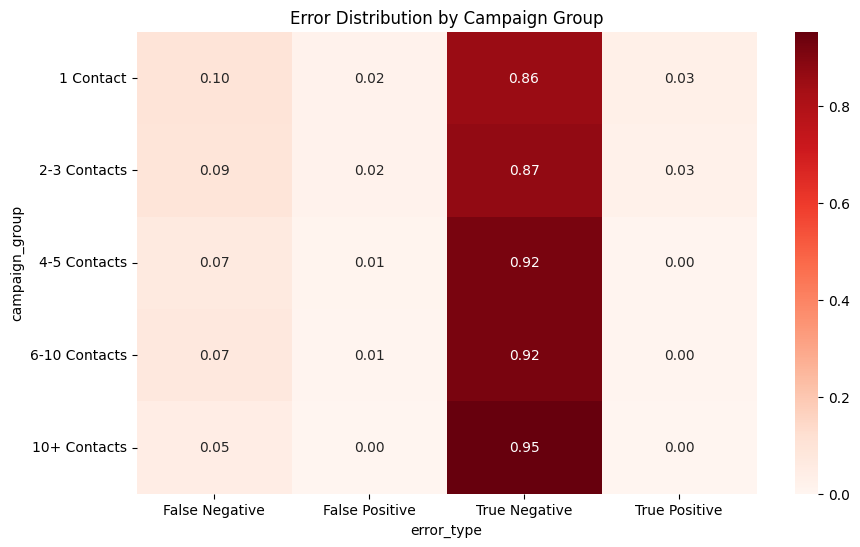

In [495]:
# Error Analysis

error_analysis = pd.crosstab(
    evaluate_model['campaign_group'],
    evaluate_model['error_type'],
    normalize='index'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    error_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('Error Distribution by Campaign Group')
plt.show()

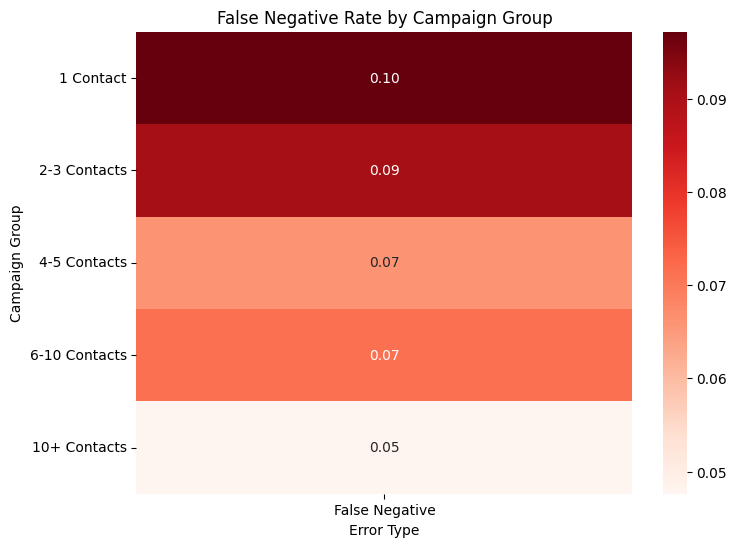

In [496]:
# Analyze False Negatives

fn_analysis = error_analysis[['False Negative']]

plt.figure(figsize=(8,6))

sns.heatmap(
    fn_analysis,
    annot=True,
    fmt='.2f',
    cmap='Reds'
)

plt.title('False Negative Rate by Campaign Group')
plt.xlabel('Error Type')
plt.ylabel('Campaign Group')

plt.show()

**OBSERVATIONS**
1. Customers contacted only once (1 Contact) had the highest false negative rate (~10%), suggesting the model struggles to identify potential subscribers early in the campaign cycle.
2. The false negative rate gradually decreases as contact frequency increases, from ~10% for 1 contact to ~5% for 10+ contacts, indicating that repeated engagement improves the model’s ability to detect likely subscribers.
3. Customers contacted more than 10 times had the lowest false negative rate, suggesting that repeated campaign interactions create stronger behavioral patterns that the model can recognize more accurately.


#### <font color=green>**Overall Strategic Insight**</br></font>
Across nearly all analyses, the model struggled most with:</br>
- younger and older customers,
- customers with incomplete demographic data,
- customers contacted through cellular campaigns,
- and customers during certain seasonal campaign periods.

This suggests that customer behavior becomes harder to predict when:</br>
- behavioral patterns are less consistent,
- demographic information is incomplete,
- or campaign timing/channel effects introduce greater variability.

These findings create strong opportunities for:</br>
- improved customer segmentation,
- targeted campaign strategies,
- enhanced data quality,
- and more advanced nonlinear models such as Random Forest or XGBoost.

#### 7. Build your second model

Now try to change something based on the process and results so far, and inspect the accuracy and confusion matrix again

- If you are happy with your features, you could tweak some parameters in your classifier
- If you had some additional features you thought may be useful, try adding them
- BONUS: you could even *create* new features based on your EDA!

<font color=green>**MODEL 2: BALANCED LOGISTIC REGRESSION**</br></font>

Improve the model to pay more attention to the minority class (response = YES)

In [497]:
#Train the model again using the same training and test data

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=27
)

log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",27
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [498]:
y_pred_balanced = log_model.predict(X_test_scaled)

y_pred_balanced

array([0, 0, 0, ..., 0, 0, 0], shape=(8238,))

In [500]:
# Classification Report
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.95      0.83      0.88      7310
           1       0.31      0.62      0.42       928

    accuracy                           0.80      8238
   macro avg       0.63      0.72      0.65      8238
weighted avg       0.87      0.80      0.83      8238



In [504]:
# Confusion Matrix
confusion_matrix_lr_balanced = confusion_matrix(y_test, y_pred_balanced)

confusion_matrix_lr_balanced

array([[6033, 1277],
       [ 350,  578]])

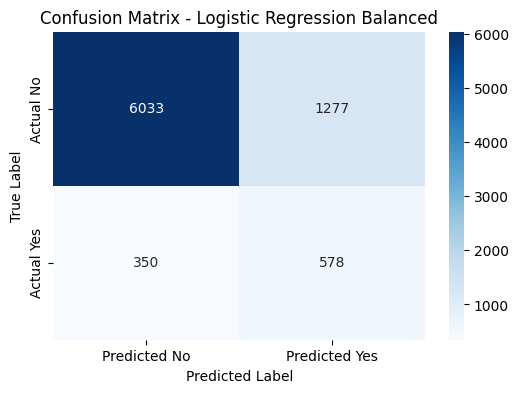

In [505]:
# Visualize the Confusion Matrix
plt.figure(figsize=(6,4))

sns.heatmap(
    confusion_matrix_lr_balanced,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted No', 'Predicted Yes'],
    yticklabels=['Actual No', 'Actual Yes']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Logistic Regression Balanced')

plt.show()


#### 8. Finally, evaluate both models on the test set

How did your two models perform? Which was better?

<font color=green>**EVALUATION OF THE 2 MODELS**</br></font>

**STRENGTHS of the BALANCED LOGISTIC REGRESSION**</br>
1. Very high improvement on Recall from 21% to 62%</br>
    The model now identifies most potential subscribers which is valuable in marketing.</br>
2. False Negatives reduced significantly from 733 to 350</br>
    This means the bank now misses far fewer opportunities</br>
3. True Positives increased dramatically from 195 to 578</br>
    The model now successfully identifies far more subscribing customers.</br>

**WEAKNESS of the BALANCED LOGISTIC REGRESSION**</br>
1. Accuracy dropped from 90% to 80%. </br>
    This is expected because the model successfully identifies far more subscribing customers.</br>
2. Precision dropped  from 61% to 31%.</br>
    This means that more false alarms and more customers targeted unnecessarily.</br>
3. False Positives increased from 125 to 1277</br>
    The bank now contacts many more non-subscribers.</br>

**WHICH MODEL IS BETTER?**</br>
Depends on the business objective.</br>

If the goal is to maximize accuracy & efficiency, then Standard Logistic Regression is better.</br>
Because of its higher accuracy, fewer wasted calls, fewer false positives and more operational efficiency.</br>
BUT it misses many actual customers who would respond with a YES (ie. subscribers).</br>

If the goal is to maximize campaign take-up, then Balanced Logistic Regression is better.</br>
Because of its much higher recall, identifies more potential subscribers and far fewer missed opportunities.</br>
This model trades off higher campaign cost with more potential sales output.</br>

For this bank's marketing goal which is to increase the likelihood of customers buying the term deposit product, 
the recommendation is the Balanced Logistic Regression.

**IN CONCLUSION**</br>
The Standard Logistic Regression model achieved higher overall accuracy and precision but demonstrated poor recall, missing a substantial number of potential subscribers.</br>
By applying class balancing, the Balanced Logistic Regression model significantly improved recall and reduced false negatives, enabling the model to identify a much larger proportion of potential subscribers.</br>
Although this resulted in increased false positives and lower accuracy, the balanced model was considered more suitable for the marketing objective of maximizing customer subscription opportunities.</br>